In [1]:
#activate venv: 

import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 29 #predictions from gw+1

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = [
        'minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles'
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > 10
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 27.32 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149259 entries, 0 to 149258
Columns: 431 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(426), object(5)
memory usage: 490.8+ MB
None


In [4]:
view = db_creator.run_sql("""SELECT
                        player_name_id, team_name, team_elo, season, event, opp_team_name, opp_team_elo, total_points, minutes, goals_scored
                            FROM playergw_transformed
                        WHERE season = 20252026 
                          AND event = 26 
                          AND player_name_id = 'Bukayo Saka'
                            """)
view

,player_name_id,team_name,team_elo,season,event,opp_team_name,opp_team_elo,total_points,minutes,goals_scored
0,Bukayo Saka,Arsenal,1249.67747,20252026.0,26.0,Brentford,1081.183298,1.0,20.0,0.0


In [5]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 288 potential features:
Total rows: 40807

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                            recoveries_p90sq_3      35526    87.06            5281
                        recoveries_elo_p90sq_3      35526    87.06            5281
                               tackles_p90sq_3      35526    87.06            5281
                           tackles_elo_p90sq_3      35526    87.06            5281
                                   cbi_p90sq_3      35526    87.06            5281
                               cbi_elo_p90sq_3      35526    87.06            5281
                        defensive_cont_p90sq_3      35526    87.06            5281
                    defensive_cont_elo_p90sq_3      35526    87.06            5281
                               tackles_p90sq_5      35481    86.95            5326
                           tackles_elo_p90sq_5      35481    86

In [6]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
   &(df['event']>20)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name','xgoals_p90sq_at']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name,xgoals_p90sq_at
132374,Bukayo Saka,21.0,3.0,Liverpool,0.364410
132376,Bukayo Saka,22.0,1.0,Nott'm Forest,0.361389
132378,Bukayo Saka,23.0,2.0,Man Utd,0.359322
132380,Bukayo Saka,24.0,0.0,Leeds,0.356240
132382,Bukayo Saka,25.0,0.0,Sunderland,0.356240
132343,Bukayo Saka,26.0,1.0,Brentford,0.356240
132362,Bukayo Saka,27.0,5.0,Spurs,0.353169
132385,Bukayo Saka,28.0,2.0,Chelsea,0.353025
132386,Bukayo Saka,29.0,9.0,Brighton,0.350034
132387,Bukayo Saka,30.0,NaN,Everton,0.347214


In [7]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [8]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [9]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [10]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [11]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

Cleaned df size: 2509/7564

Training Set Performance:
R² Score: 0.8375
RMSE: 13.2158
MAE: 10.9852

Test Set Performance:
R² Score: 0.3481
RMSE: 26.7125
MAE: 21.6690

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.234126
           minutes_elo_3    0.067129
    opp_team_elo_p90sq_3    0.053038
    opp_team_elo_p90sq_5    0.023653
        team_elo_p90sq_3    0.018628
       team_elo_p90sq_at    0.018456
   opp_team_elo_p90sq_at    0.011375
opp_team_elo_elo_p90sq_3    0.009142
            opp_team_elo    0.009086
       team_elo_p90sq_10    0.008964
          opp_team_elo_5    0.008093
         opp_team_elo_10    0.007775
                elo_diff    0.007605
                team_elo    0.007417
 goals_conceded_p90sq_at    0.007197
   clean_sheets_p90sq_at    0.006590
   total_points_p90sq_at    0.006398
        team_elo_p90sq_5    0.006361
            bps_p90sq_at    0.006274
          opp_team_elo_3    0.005684


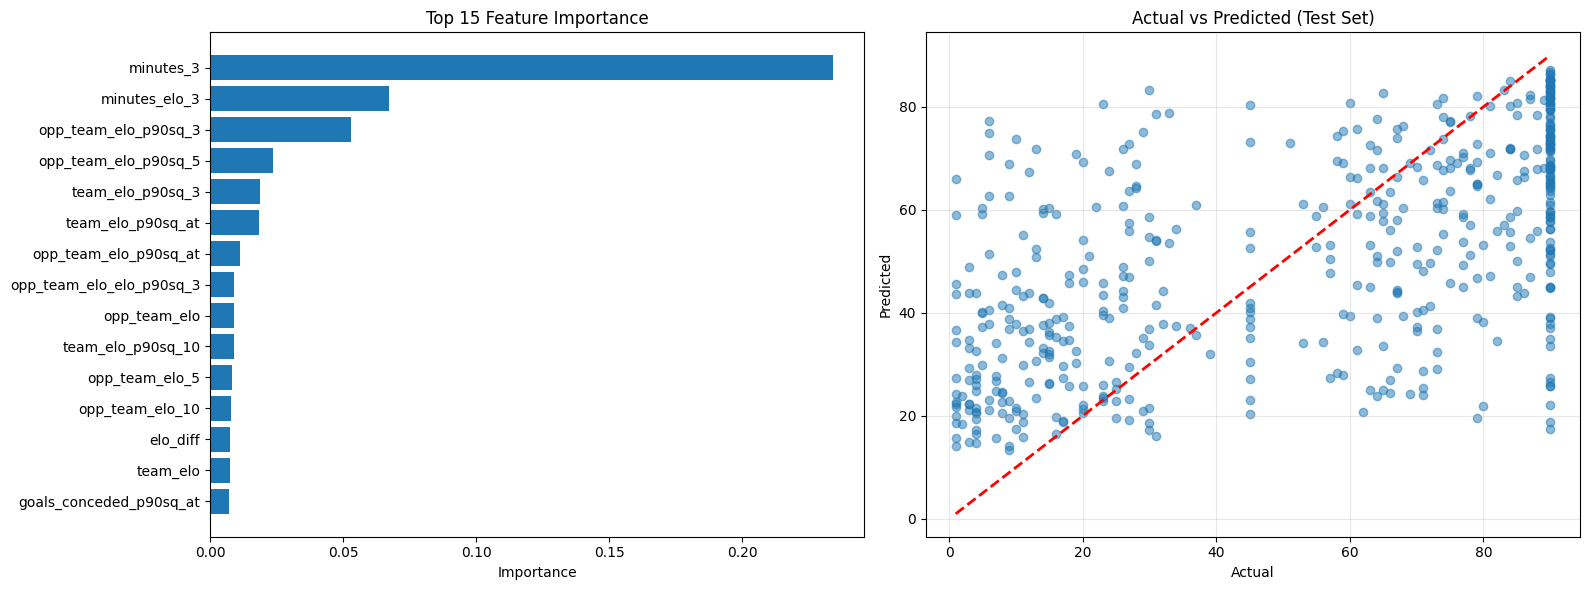

Cleaned df size: 8700/28245

Training Set Performance:
R² Score: 0.6647
RMSE: 18.5896
MAE: 15.3108

Test Set Performance:
R² Score: 0.3243
RMSE: 26.2958
MAE: 21.6845

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.373606
    opp_team_elo_p90sq_3    0.019794
                  bps_10    0.018592
   opp_team_elo_p90sq_10    0.018177
    opp_team_elo_p90sq_5    0.013907
        team_elo_p90sq_5    0.010027
              minutes_10    0.008999
          minutes_elo_10    0.008813
       minutes_elo_p90_5    0.008581
         xg_over_g_ratio    0.008163
            opp_team_elo    0.007761
 goals_conceded_p90sq_at    0.007241
          opp_team_elo_3    0.007179
   clean_sheets_p90sq_at    0.007056
       team_elo_p90sq_10    0.006814
           minutes_elo_3    0.006766
xgoals_conceded_p90sq_at    0.006669
         opp_team_elo_10    0.006513
          opp_team_elo_5    0.006220
              bps_elo_10    0.006058


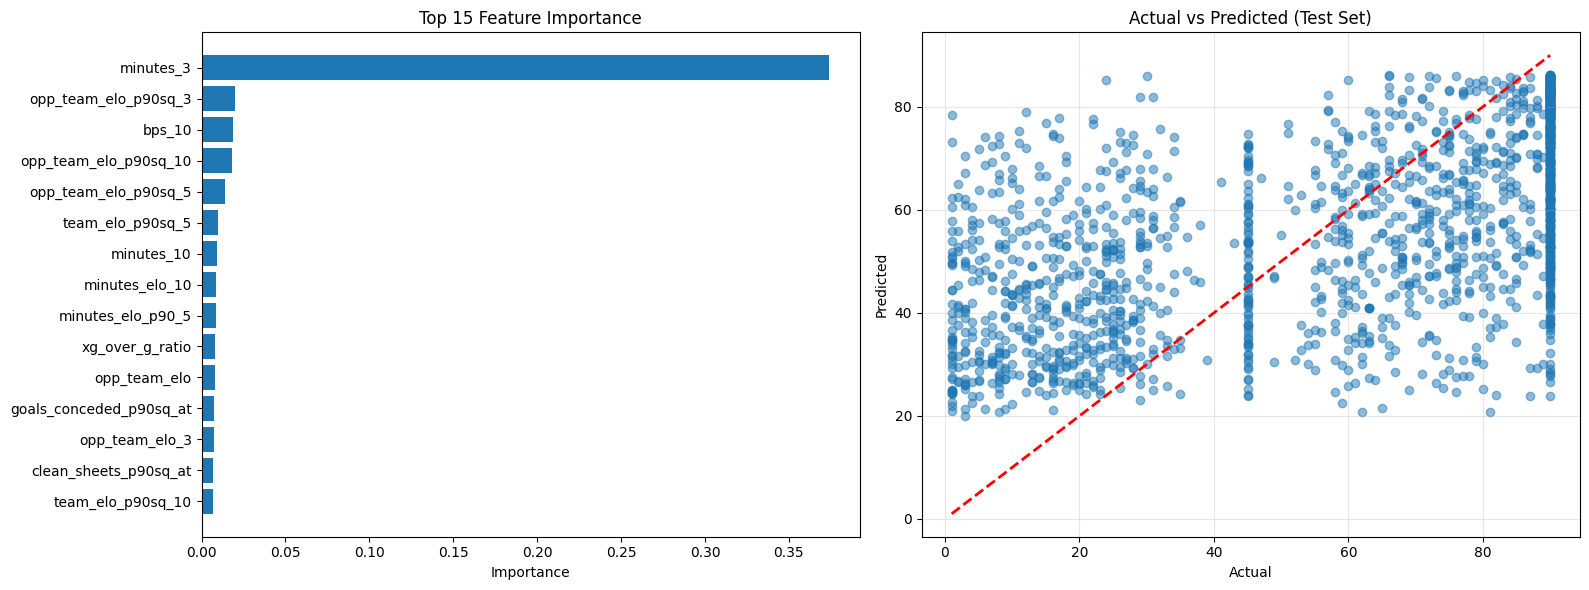

Cleaned df size: 5367/20355

Training Set Performance:
R² Score: 0.6785
RMSE: 16.6157
MAE: 12.4483

Test Set Performance:
R² Score: 0.1959
RMSE: 26.6548
MAE: 19.5257

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.185364
        team_elo_p90sq_3    0.040451
    opp_team_elo_p90sq_3    0.033358
   opp_team_elo_p90sq_10    0.019229
       team_elo_p90sq_10    0.018093
       xassists_p90sq_at    0.013734
         xg_over_g_ratio    0.012534
          opp_team_elo_3    0.011779
         opp_team_elo_10    0.011402
           minutes_elo_3    0.010732
            opp_team_elo    0.009648
 goals_conceded_p90sq_at    0.009415
  opp_team_elo_elo_p90_5    0.008696
                elo_diff    0.008088
   goals_scored_p90sq_at    0.008078
          opp_team_elo_5    0.008060
xgoals_conceded_p90sq_at    0.007934
   total_points_p90sq_at    0.007590
opp_team_elo_elo_p90sq_3    0.007554
          bonus_p90sq_at    0.007346


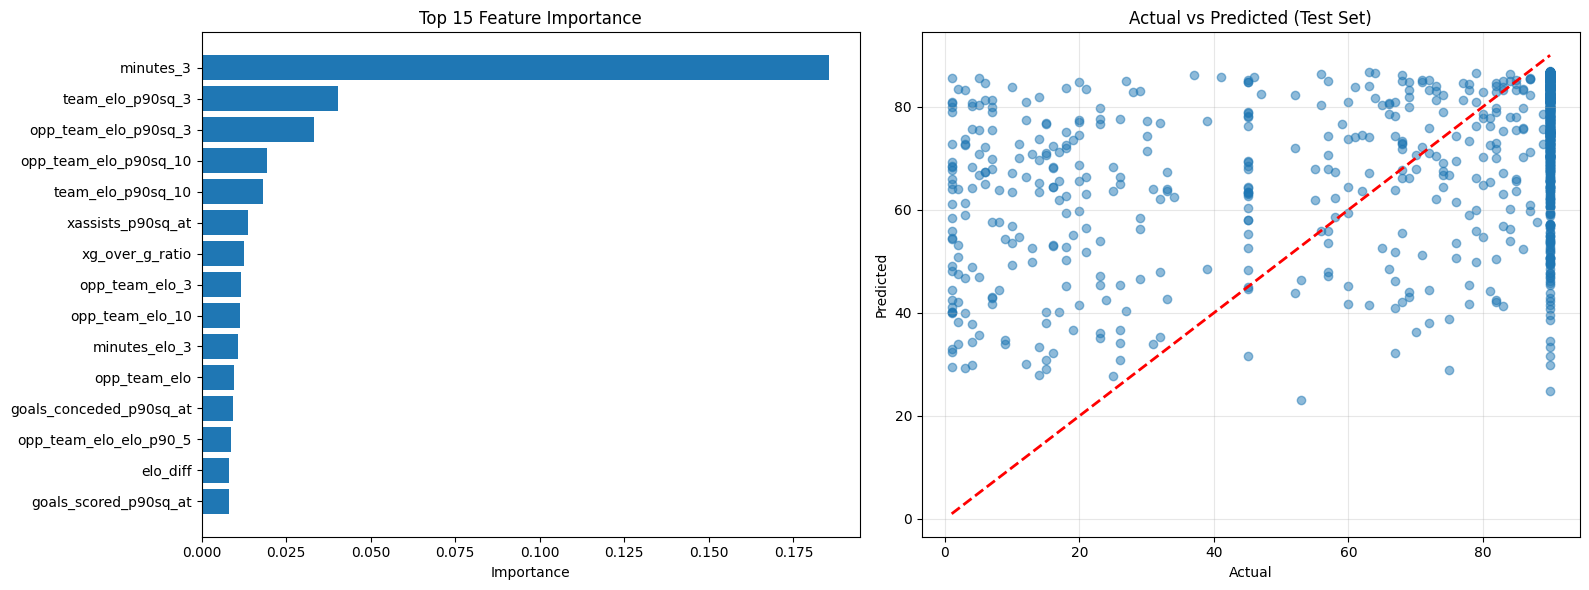

Cleaned df size: 3934/4200

Training Set Performance:
R² Score: 0.7101
RMSE: 2.8878
MAE: 0.6329

Test Set Performance:
R² Score: -0.1916
RMSE: 4.3242
MAE: 1.0018

Top 20 Feature Importances:
                feature  importance
            bps_p90sq_3    0.041881
           opp_team_elo    0.030751
           bps_p90sq_at    0.030282
         team_elo_elo_3    0.029526
  opp_team_elo_p90sq_at    0.028590
         opp_team_elo_5    0.027813
                 bps_10    0.025171
            bps_p90sq_5    0.020817
  total_points_p90sq_10    0.018822
         saves_p90sq_10    0.017936
goals_conceded_p90sq_at    0.017058
      saves_elo_p90sq_3    0.016838
        opp_team_elo_10    0.015982
          minutes_elo_3    0.015639
  goals_conceded_elo_10    0.013561
  total_points_p90sq_at    0.013242
      team_elo_p90sq_at    0.012686
     saves_elo_p90sq_10    0.012546
    minutes_elo_p90sq_3    0.012533
   total_points_p90sq_5    0.012044


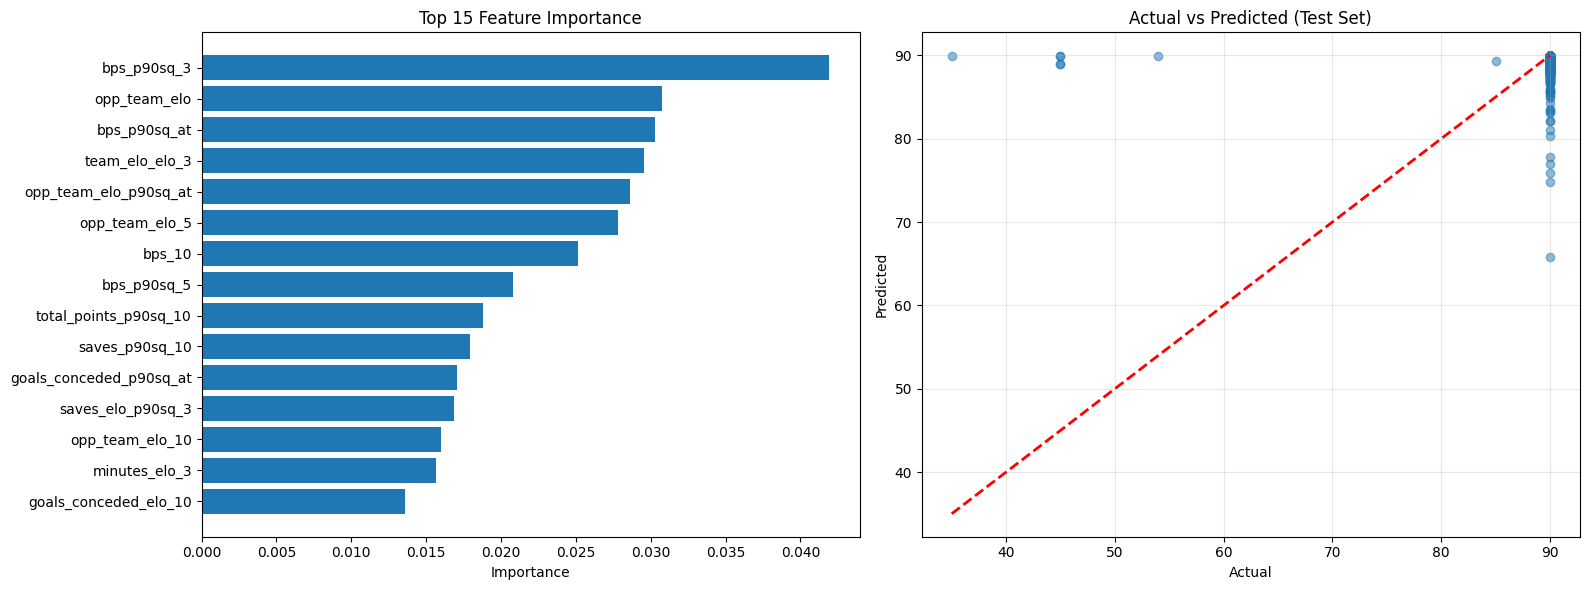

In [12]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2629/4341

Training Set Performance:
R² Score: 0.5909
RMSE: 0.2476
MAE: 0.1982

Test Set Performance:
R² Score: 0.0488
RMSE: 0.3866
MAE: 0.2902

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.034337
    goals_scored_p90sq_at    0.028992
          xg_over_g_ratio    0.023812
           opp_team_elo_5    0.019898
             opp_team_elo    0.019541
           opp_team_elo_3    0.016975
         team_elo_p90sq_3    0.016461
          opp_team_elo_10    0.015462
            minutes_elo_3    0.014502
     opp_team_elo_p90sq_3    0.014085
           bonus_p90sq_at    0.013499
        team_elo_p90sq_at    0.013201
      goals_scored_elo_10    0.011931
    clean_sheets_p90sq_at    0.011915
        minutes_elo_p90_3    0.011854
      total_points_p90_10    0.011746
total_points_elo_p90sq_10    0.011445
  goals_conceded_p90sq_at    0.011366
  goals_scored_elo_p90_10    0.011301
    

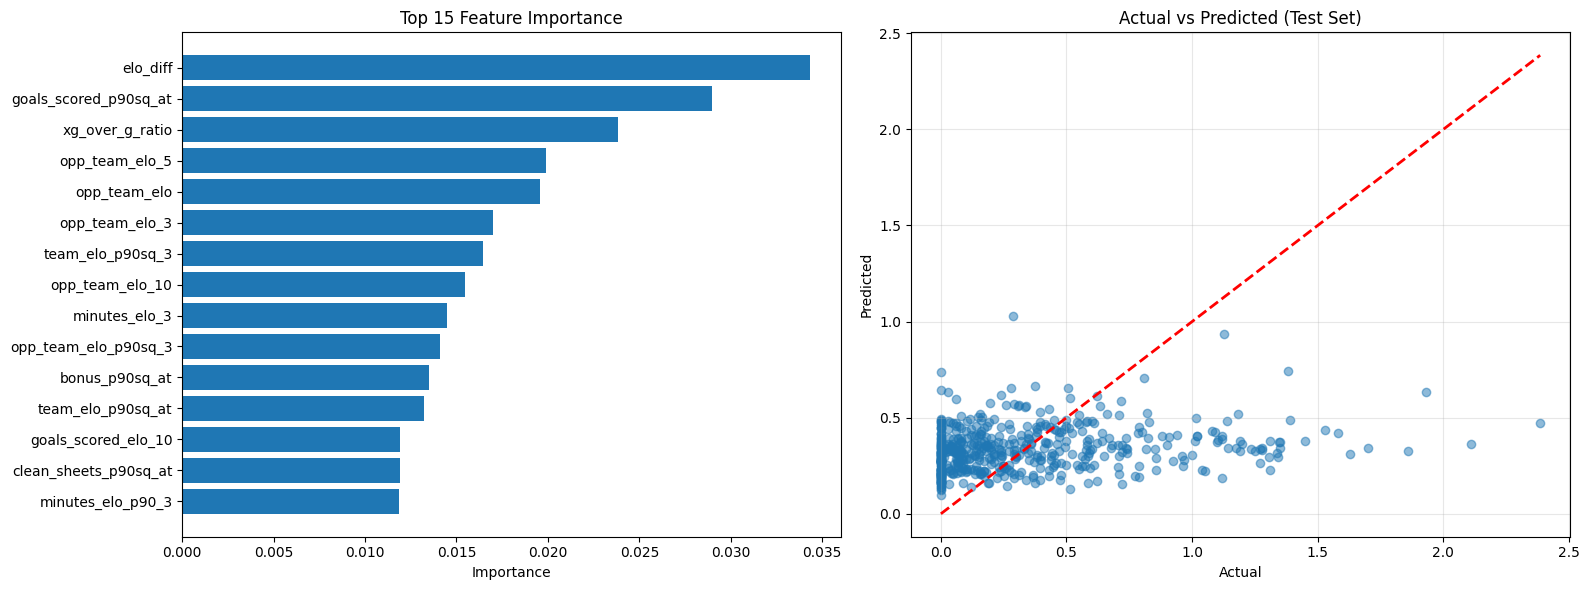

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 12144/18563

Training Set Performance:
R² Score: 0.3863
RMSE: 0.1754
MAE: 0.1187

Test Set Performance:
R² Score: 0.0811
RMSE: 0.2050
MAE: 0.1350

Top 20 Feature Importances:
                feature  importance
  goals_scored_p90sq_at    0.145678
           opp_team_elo    0.037877
         bonus_p90sq_at    0.022563
               elo_diff    0.021305
        opp_team_elo_10    0.019605
  clean_sheets_p90sq_at    0.015921
    goals_scored_elo_10    0.015253
           bps_p90sq_10    0.014024
         opp_team_elo_5    0.013785
         opp_team_elo_3    0.013648
           bps_p90sq_at    0.013562
    total_points_elo_10    0.012008
goals_conceded_p90sq_at    0.011969
             bps_elo_10    0.011673
      team_elo_p90sq_at    0.011541
  total_points_p90sq_at    0.011153
       bps_elo_p90sq_10    0.011135
   total_points_p90sq_3    0.009945
             bps_p90_10    0.009552
   goals_conceded_elo_5    0.009030


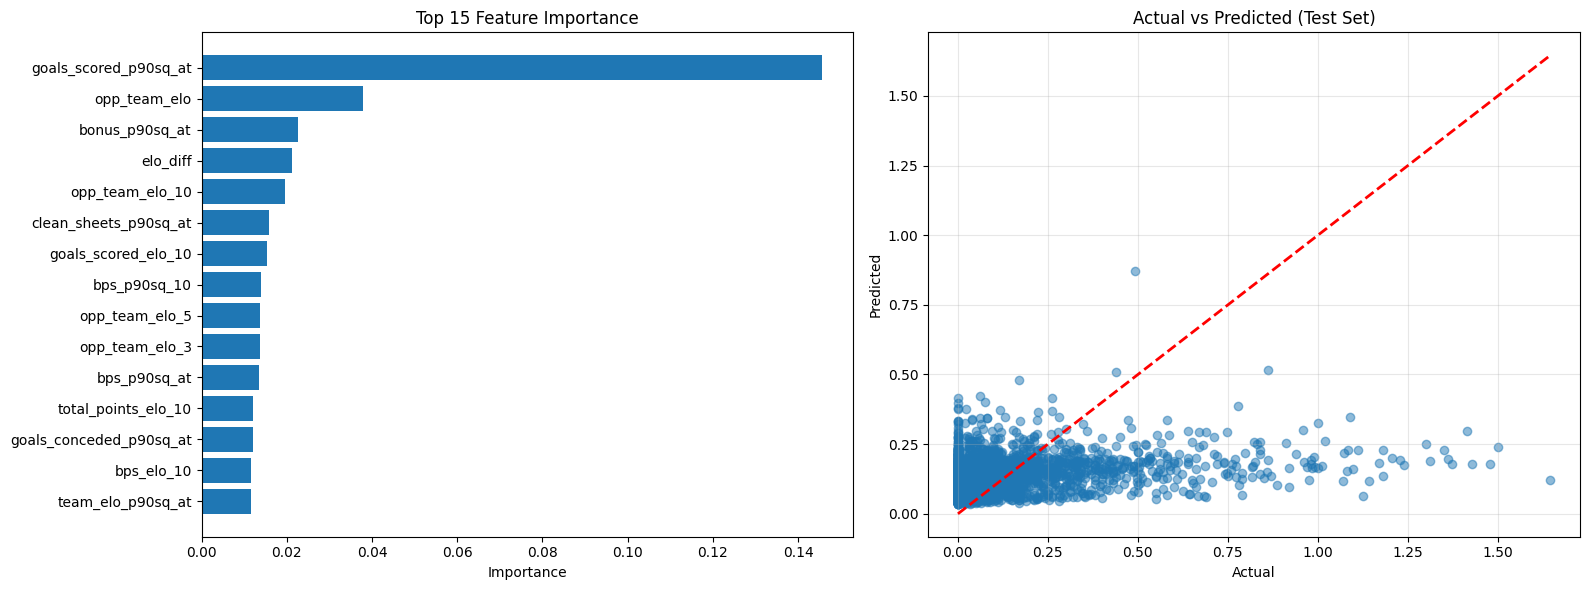

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 10402/16608

Training Set Performance:
R² Score: 0.2668
RMSE: 0.0926
MAE: 0.0555

Test Set Performance:
R² Score: -0.0117
RMSE: 0.1000
MAE: 0.0597

Top 20 Feature Importances:
                    feature  importance
      goals_scored_p90sq_at    0.040311
               opp_team_elo    0.039024
             opp_team_elo_3    0.036057
             opp_team_elo_5    0.021660
    goals_conceded_p90sq_at    0.021090
                   elo_diff    0.021050
          team_elo_p90sq_at    0.020663
      opp_team_elo_p90sq_10    0.018095
               bps_p90sq_at    0.016881
      total_points_p90sq_at    0.015183
      goals_conceded_elo_10    0.014892
        goals_scored_elo_10    0.014875
goals_conceded_elo_p90sq_10    0.014702
      total_points_p90sq_10    0.014298
            opp_team_elo_10    0.013429
         total_points_p90_5    0.012056
       opp_team_elo_p90sq_3    0.011634
         total_points_elo_5    0.011617
 

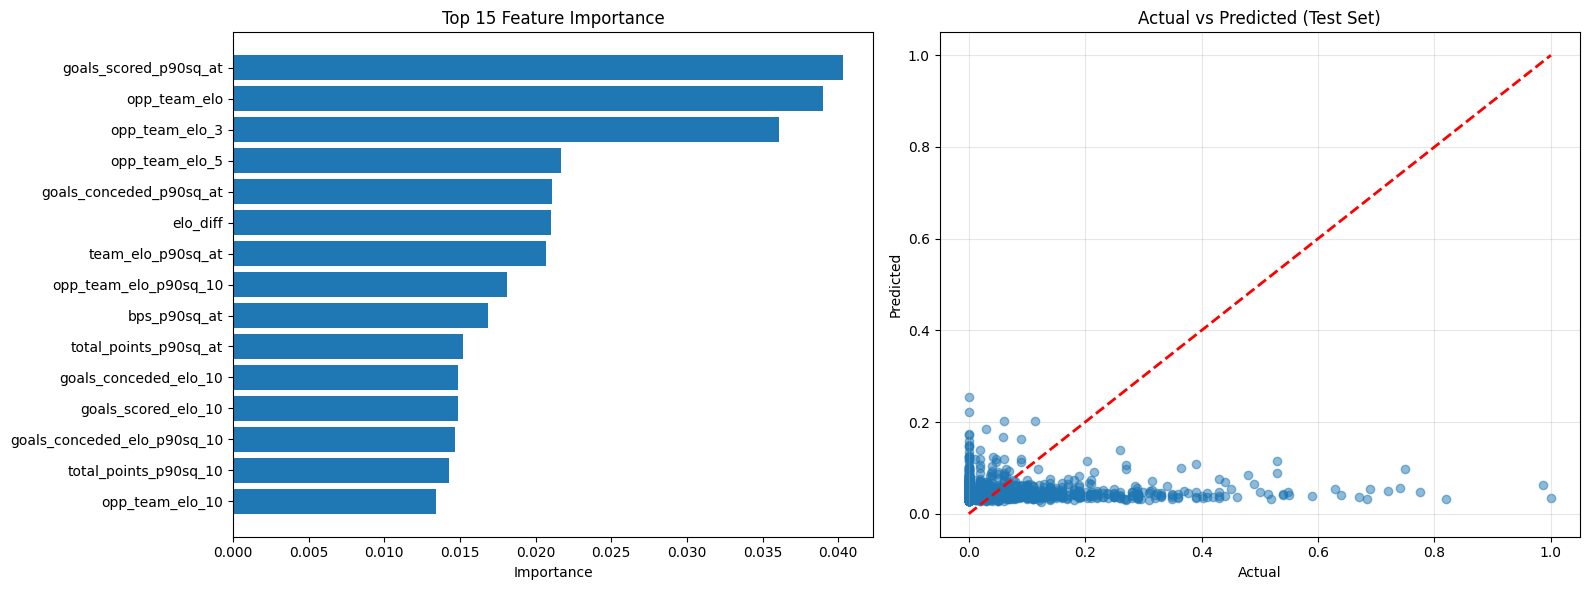

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 2824/4626

Training Set Performance:
R² Score: 0.5639
RMSE: 0.0782
MAE: 0.0534

Test Set Performance:
R² Score: 0.0110
RMSE: 0.1279
MAE: 0.0760

Top 20 Feature Importances:
              feature  importance
         opp_team_elo    0.047589
       opp_team_elo_3    0.032155
             elo_diff    0.024092
           bps_elo_10    0.023509
      xg_over_g_ratio    0.019410
 total_points_p90sq_3    0.017153
goals_scored_p90sq_at    0.014036
    minutes_elo_p90_3    0.013521
    team_elo_p90sq_at    0.013031
      opp_team_elo_10    0.012902
          bps_p90sq_3    0.012544
      bps_elo_p90sq_3    0.012005
         bonus_elo_10    0.011755
    minutes_elo_p90_5    0.011244
        minutes_elo_5    0.010990
       minutes_elo_10    0.010915
   minutes_elo_p90_10    0.010904
total_points_p90sq_10    0.010711
  minutes_elo_p90sq_5    0.010563
  total_points_elo_10    0.010351


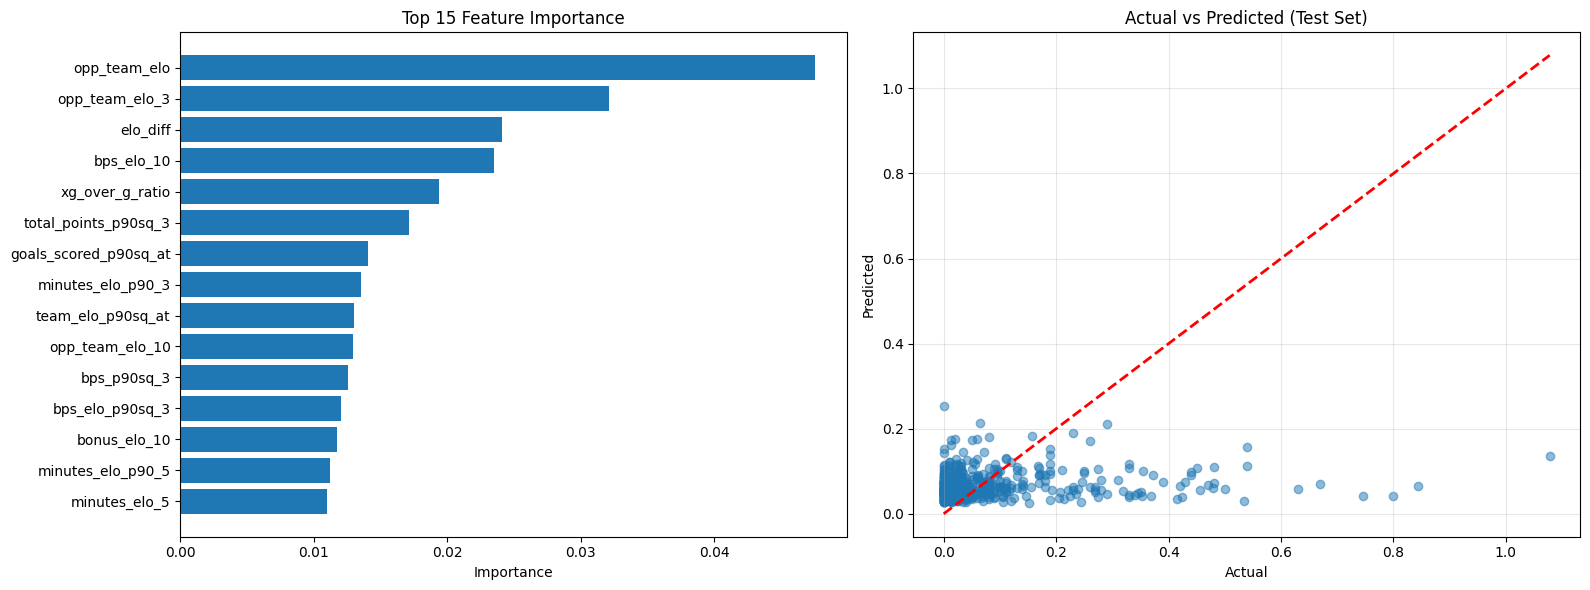

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 12576/19199

Training Set Performance:
R² Score: 0.4234
RMSE: 0.1260
MAE: 0.0895

Test Set Performance:
R² Score: 0.0564
RMSE: 0.1456
MAE: 0.1026

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.083811
         bonus_p90sq_at    0.058878
    total_points_elo_10    0.044470
             bps_elo_10    0.041962
           opp_team_elo    0.025167
  goals_scored_p90sq_at    0.021287
  total_points_p90sq_at    0.013998
           bps_p90sq_at    0.013960
         opp_team_elo_5    0.013792
        opp_team_elo_10    0.013102
  clean_sheets_p90sq_at    0.012375
      team_elo_p90sq_at    0.011671
                 bps_10    0.011275
goals_conceded_p90sq_at    0.010644
               team_elo    0.009380
  opp_team_elo_p90sq_at    0.009305
          bps_elo_p90_5    0.008765
             bps_p90_10    0.008712
         opp_team_elo_3    0.008678
             minutes_10    0.008523


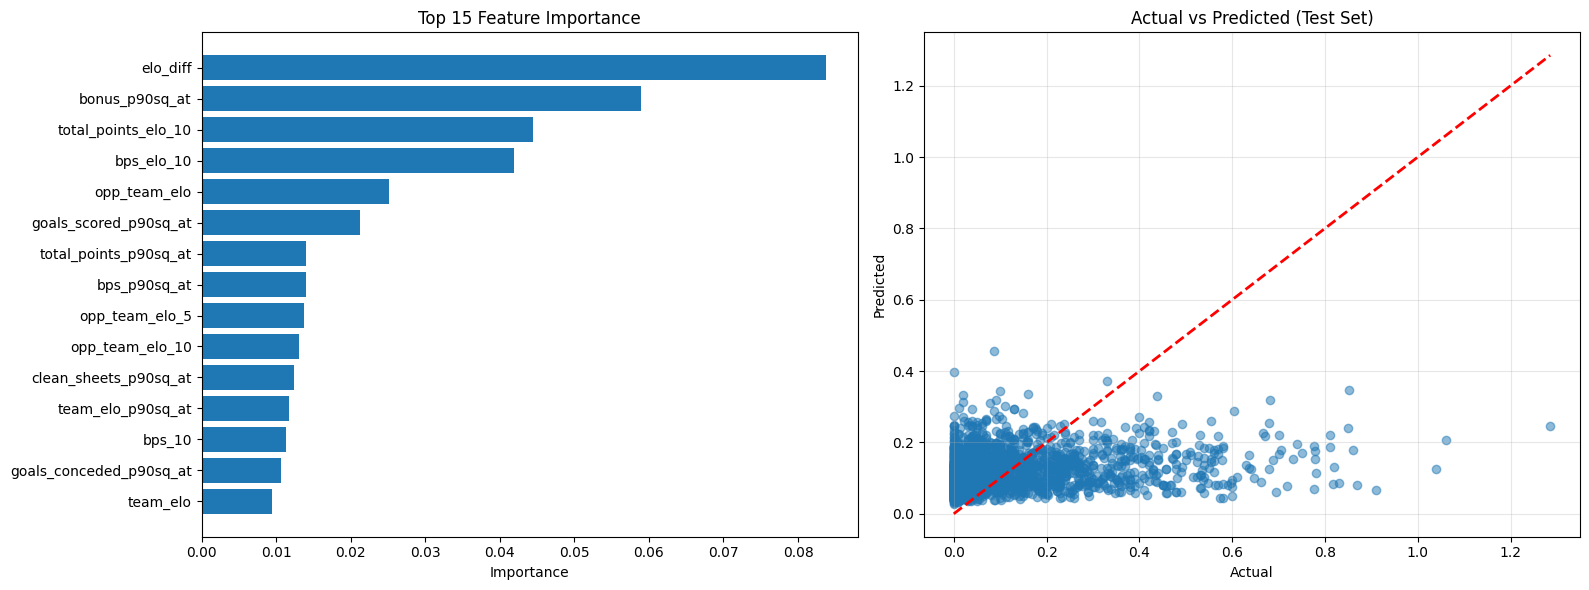

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 10600/16931

Training Set Performance:
R² Score: 0.3680
RMSE: 0.0846
MAE: 0.0516

Test Set Performance:
R² Score: 0.0338
RMSE: 0.0954
MAE: 0.0569

Top 20 Feature Importances:
                feature  importance
         bonus_p90sq_at    0.106286
               elo_diff    0.034393
           opp_team_elo    0.033972
goals_conceded_p90sq_at    0.026241
    minutes_elo_p90sq_3    0.021562
  goals_scored_p90sq_at    0.017471
    total_points_p90_10    0.017434
          bps_elo_p90_5    0.016604
                  bps_3    0.016374
        opp_team_elo_10    0.016247
               team_elo    0.014935
         opp_team_elo_3    0.014693
            bps_p90sq_5    0.013925
 opp_team_elo_elo_p90_3    0.012859
  clean_sheets_p90sq_at    0.011495
                 bps_10    0.011173
      team_elo_p90sq_at    0.010907
   goals_conceded_elo_3    0.010564
         minutes_elo_10    0.010309
         bps_elo_p90_10    0.010277


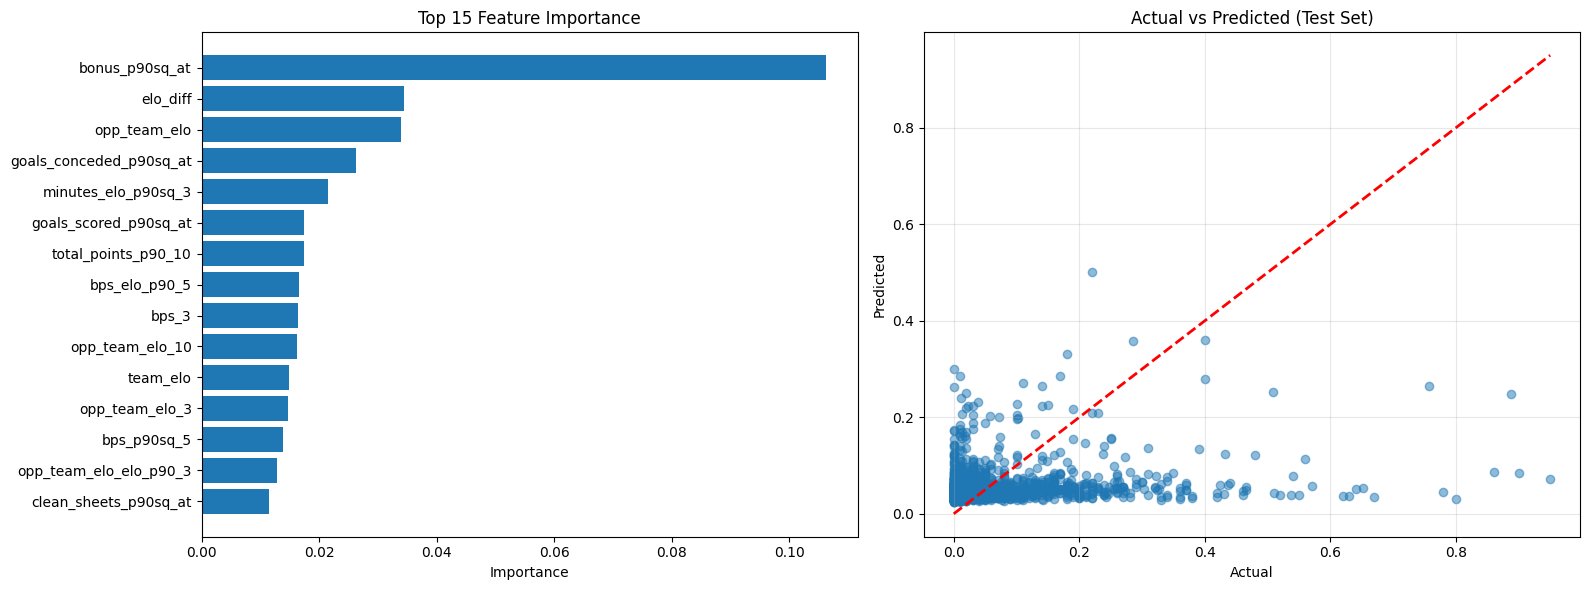

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 2824/4626

Training Set Performance:
R² Score: 0.6634
RMSE: 0.5380
MAE: 0.4335

Test Set Performance:
R² Score: 0.1180
RMSE: 0.8725
MAE: 0.6724

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.161250
            xg_over_g_ratio    0.042900
               opp_team_elo    0.042305
      clean_sheets_p90sq_at    0.019621
             opp_team_elo_5    0.015274
            opp_team_elo_10    0.014986
    goals_conceded_p90sq_at    0.014679
         minutes_elo_p90_10    0.012253
             opp_team_elo_3    0.010986
goals_conceded_elo_p90sq_10    0.010574
      goals_scored_p90sq_at    0.009956
        minutes_elo_p90sq_3    0.009674
      opp_team_elo_p90sq_at    0.009404
                 minutes_10    0.009389
      total_points_p90sq_at    0.009388
      goals_conceded_elo_10    0.008839
          team_elo_p90sq_at    0.008364
 goals_conceded_elo_p90sq_5    0.0

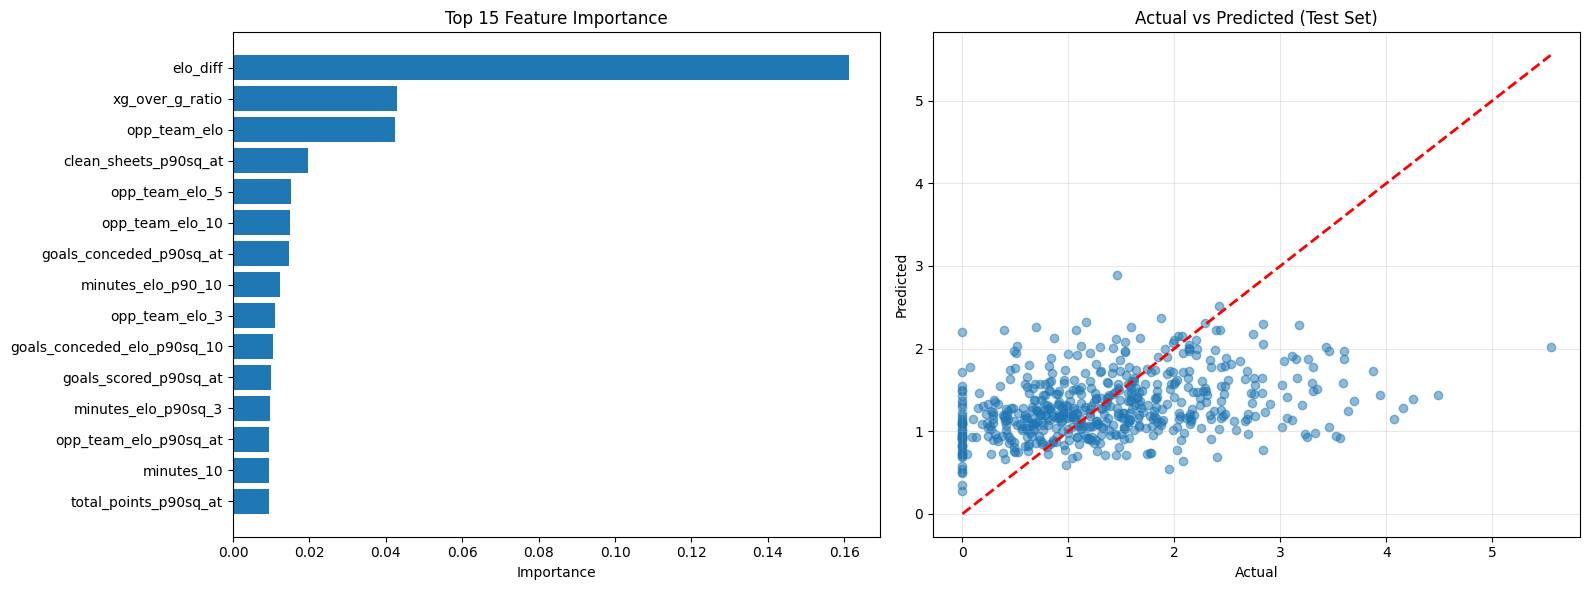

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 12576/19199

Training Set Performance:
R² Score: 0.5391
RMSE: 0.6301
MAE: 0.5018

Test Set Performance:
R² Score: 0.3144
RMSE: 0.7919
MAE: 0.6115

Top 20 Feature Importances:
              feature  importance
             elo_diff    0.251458
         opp_team_elo    0.073880
      opp_team_elo_10    0.038547
       opp_team_elo_5    0.038424
             team_elo    0.028237
       opp_team_elo_3    0.024953
           team_elo_5    0.020966
          team_elo_10    0.020081
           team_elo_3    0.018999
       team_elo_elo_3    0.018190
   opp_team_elo_elo_5    0.018009
   opp_team_elo_elo_3    0.016623
       team_elo_elo_5    0.016414
  minutes_elo_p90sq_3    0.013748
    minutes_elo_p90_3    0.011680
  opp_team_elo_elo_10    0.011234
clean_sheets_p90sq_at    0.011229
      team_elo_elo_10    0.010541
    minutes_elo_p90_5    0.009173
  minutes_elo_p90sq_5    0.008902


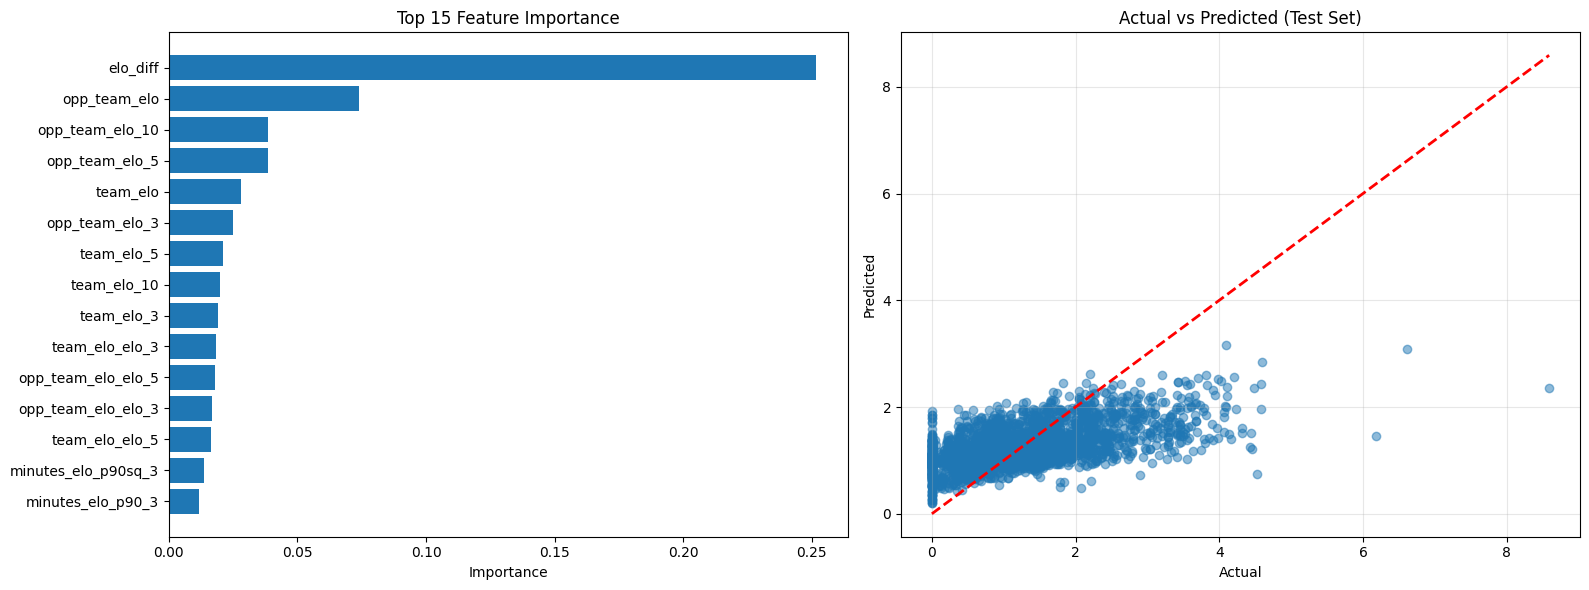

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 10600/16931

Training Set Performance:
R² Score: 0.5713
RMSE: 0.6109
MAE: 0.4865

Test Set Performance:
R² Score: 0.2930
RMSE: 0.7860
MAE: 0.5981

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.220123
           opp_team_elo    0.078208
        opp_team_elo_10    0.034738
         opp_team_elo_5    0.030797
         opp_team_elo_3    0.023371
            team_elo_10    0.022053
    opp_team_elo_elo_10    0.021378
             team_elo_5    0.020967
               team_elo    0.019219
  clean_sheets_p90sq_at    0.017348
     opp_team_elo_elo_3    0.016467
         team_elo_elo_3    0.016298
goals_conceded_p90sq_at    0.016140
             team_elo_3    0.014423
     opp_team_elo_elo_5    0.013622
         team_elo_elo_5    0.012884
    minutes_elo_p90sq_3    0.012272
      minutes_elo_p90_3    0.011146
        team_elo_elo_10    0.010870
      team_elo_p90sq_at    0.008

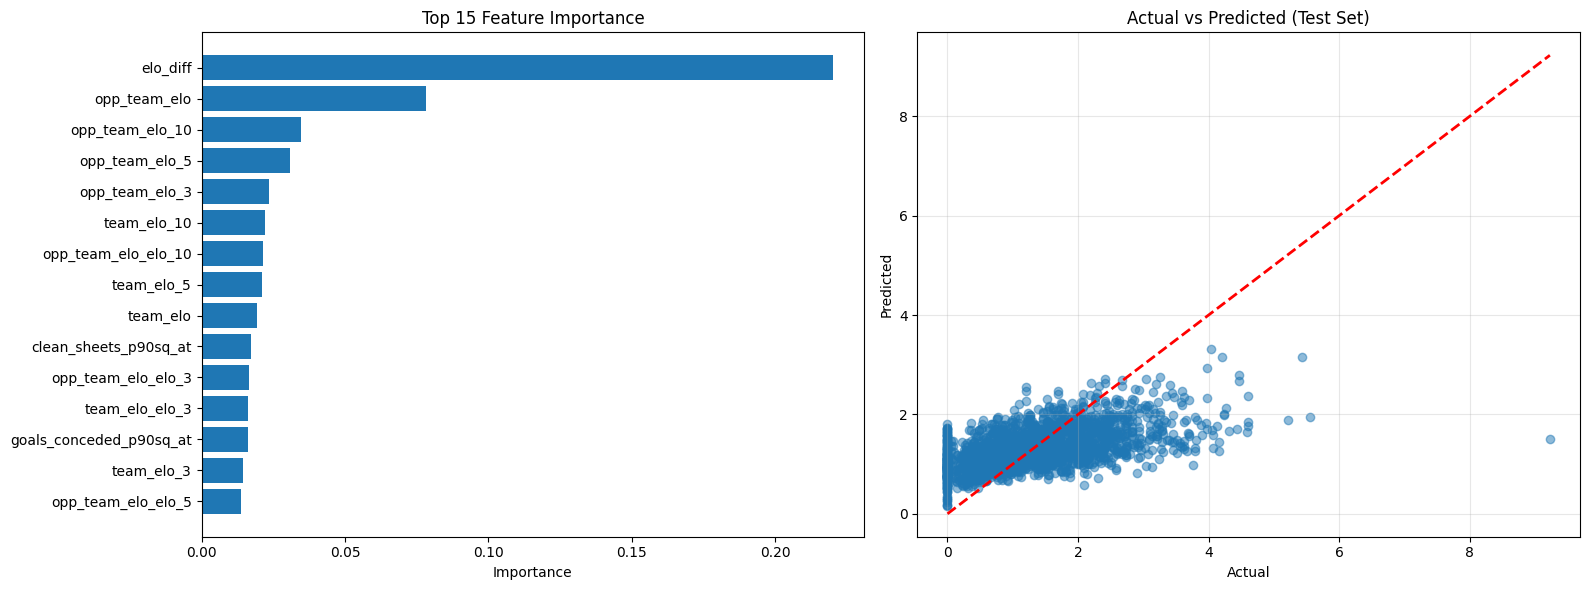

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 2599/4138

Training Set Performance:
R² Score: 0.7070
RMSE: 0.5015
MAE: 0.4019

Test Set Performance:
R² Score: 0.1023
RMSE: 0.8376
MAE: 0.6669

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.153564
           opp_team_elo    0.058524
         saves_p90sq_at    0.030759
  opp_team_elo_p90sq_at    0.022936
  opp_team_elo_p90sq_10    0.022166
      team_elo_p90sq_at    0.021175
goals_conceded_p90sq_at    0.020254
        opp_team_elo_10    0.019991
           bps_p90sq_at    0.015832
     saves_elo_p90sq_10    0.015789
         saves_p90sq_10    0.015663
  clean_sheets_p90sq_at    0.014258
         opp_team_elo_5    0.012979
  total_points_p90sq_at    0.012757
      saves_elo_p90sq_3    0.012161
      saves_elo_p90sq_5    0.011948
         bonus_p90sq_at    0.011503
           bps_p90sq_10    0.011098
          saves_p90sq_5    0.010044
   opp_team_elo_p90sq_5    0.009684

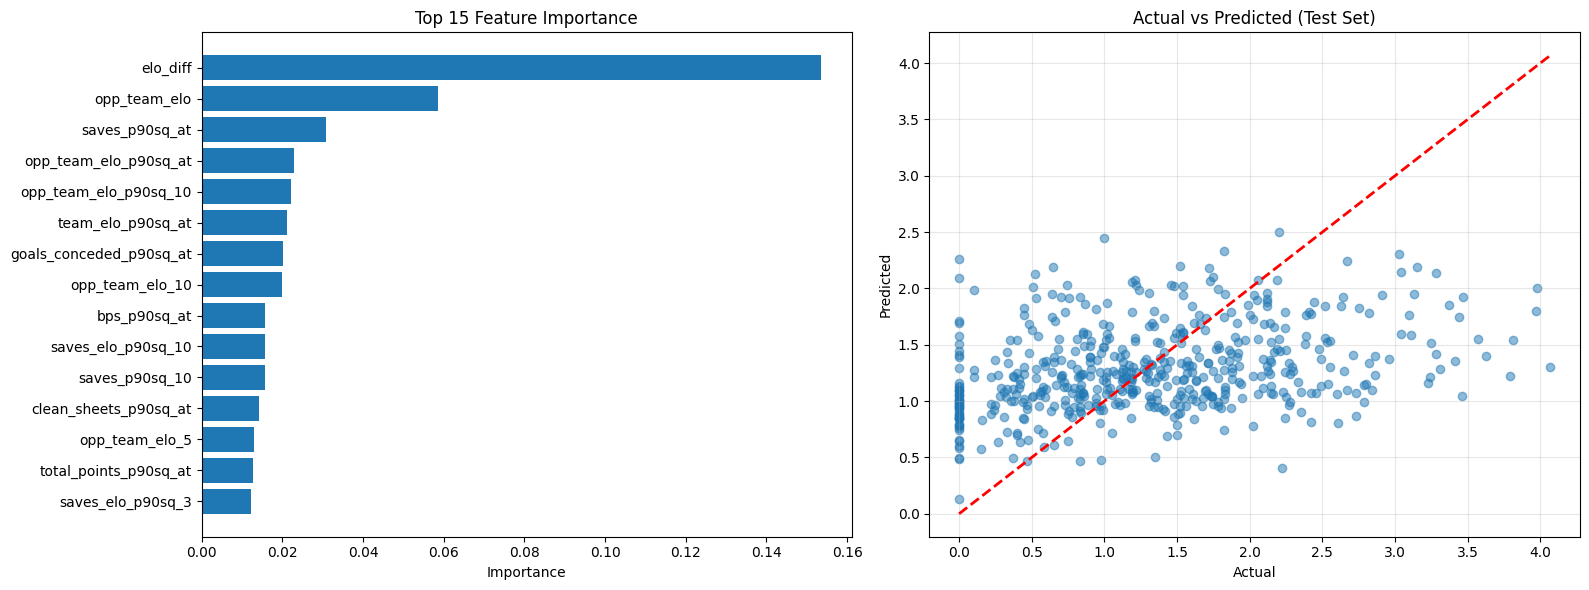

In [15]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4136/4626

Training Set Performance:
R² Score: 0.4872
RMSE: 13.2779
MAE: 10.7499

Test Set Performance:
R² Score: 0.0127
RMSE: 18.3255
MAE: 14.1824

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.075499
             opp_team_elo    0.023708
       opp_team_elo_elo_5    0.016871
  goals_conceded_p90sq_at    0.016695
           opp_team_elo_5    0.015707
          opp_team_elo_10    0.015273
clean_sheets_elo_p90sq_10    0.013373
                bps_elo_3    0.013283
      minutes_elo_p90sq_3    0.012865
             bps_p90sq_at    0.012558
           opp_team_elo_3    0.012493
      minutes_elo_p90sq_5    0.011765
        minutes_elo_p90_3    0.011740
           bonus_p90sq_at    0.011728
    clean_sheets_p90sq_at    0.011257
              bps_p90sq_5    0.010165
total_points_elo_p90sq_10    0.009509
    goals_scored_p90sq_at    0.009419
    total_points_p90sq_at    0.009341
          

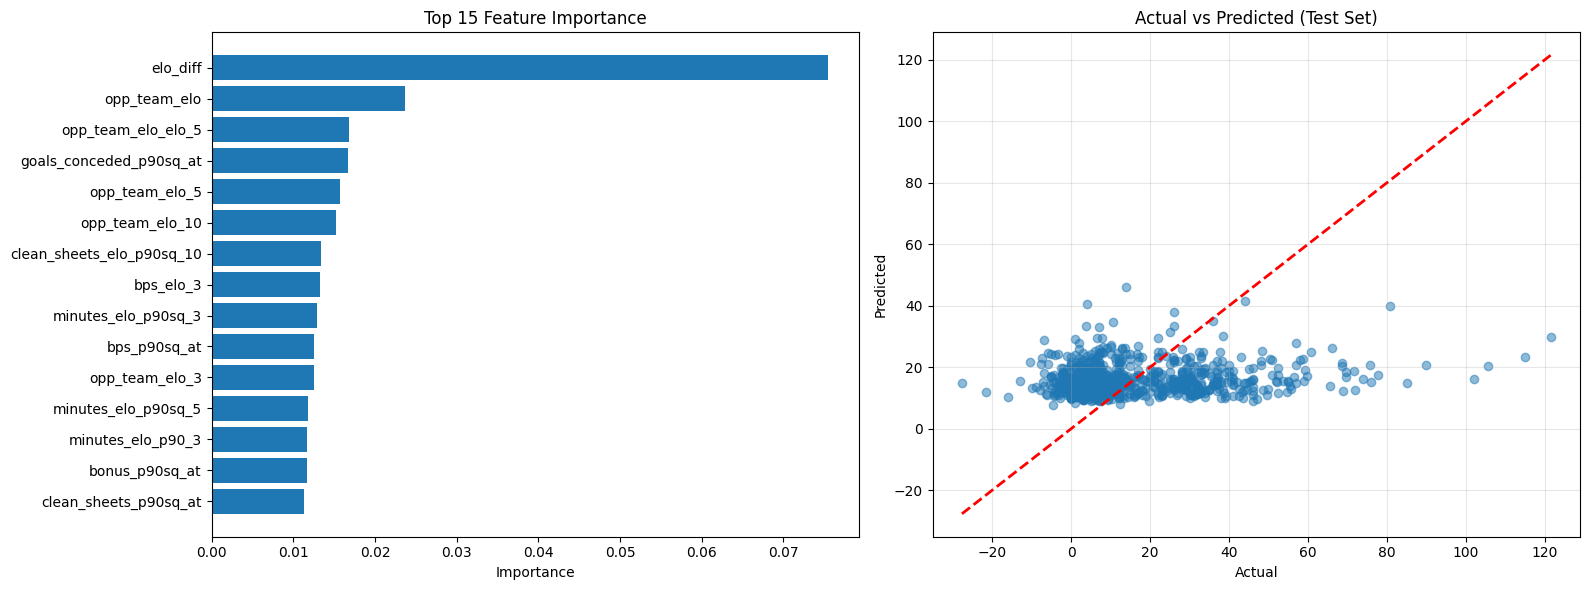

target=bps_per90, MID_bps_predictor
Cleaned df size: 18590/19199

Training Set Performance:
R² Score: 0.3146
RMSE: 9.5392
MAE: 7.2496

Test Set Performance:
R² Score: 0.0471
RMSE: 10.9588
MAE: 7.9593

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.113124
             bps_elo_10    0.050877
                 bps_10    0.029958
           opp_team_elo    0.023779
         bonus_p90sq_at    0.021464
        opp_team_elo_10    0.017438
         opp_team_elo_3    0.016900
                  bps_5    0.016465
      team_elo_p90sq_at    0.013476
  goals_scored_p90sq_at    0.010876
         opp_team_elo_5    0.010669
goals_conceded_p90sq_at    0.010171
              bps_elo_5    0.009777
           bps_p90sq_at    0.009638
  clean_sheets_p90sq_at    0.009597
             bps_p90_10    0.009388
    total_points_elo_10    0.008981
  total_points_p90sq_at    0.008797
goals_conceded_p90sq_10    0.008671
         minutes_elo_10    0.008576


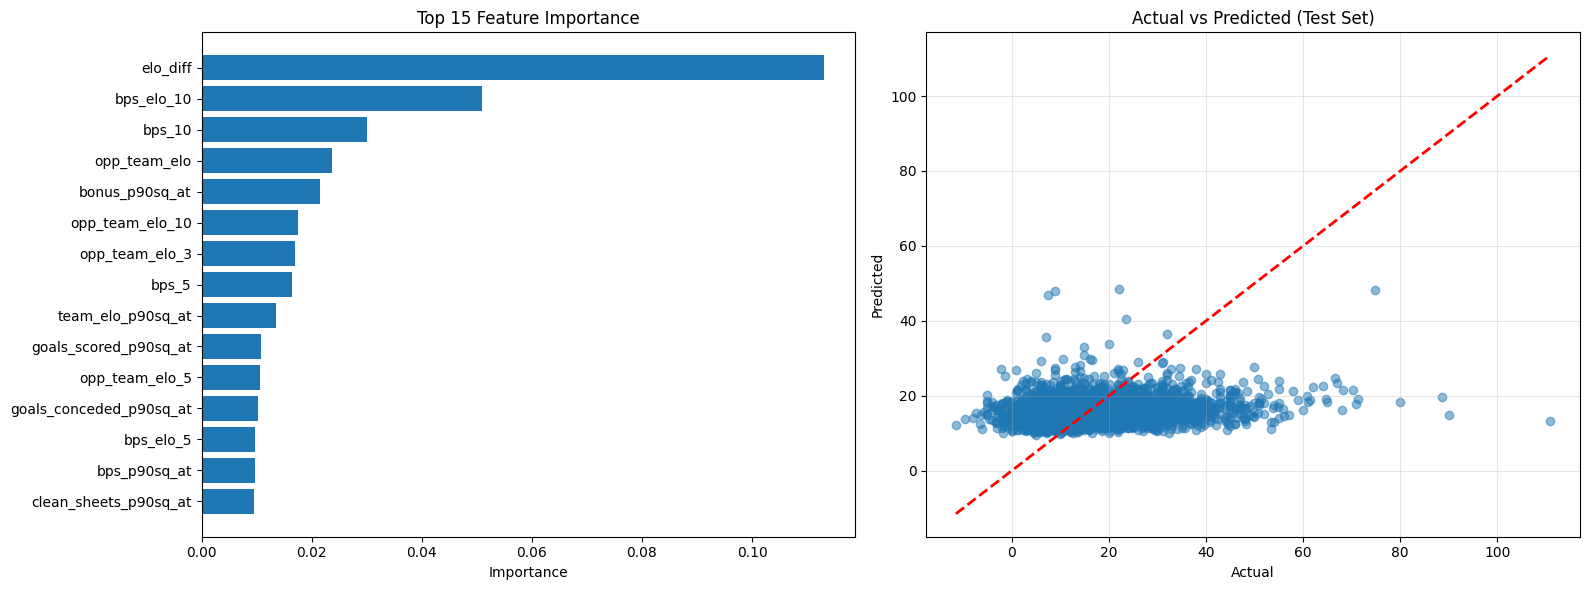

target=bps_per90, DEF_bps_predictor
Cleaned df size: 15927/16931

Training Set Performance:
R² Score: 0.4115
RMSE: 7.5914
MAE: 6.0772

Test Set Performance:
R² Score: 0.1458
RMSE: 9.1230
MAE: 7.1778

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.234660
           opp_team_elo    0.030640
        opp_team_elo_10    0.030167
         opp_team_elo_5    0.023265
         opp_team_elo_3    0.019616
             bps_p90_10    0.014649
         bonus_p90sq_at    0.013767
goals_conceded_p90sq_at    0.012411
                 bps_10    0.011735
           bps_p90sq_at    0.010988
  clean_sheets_p90sq_at    0.010983
               team_elo    0.010914
            bps_p90sq_5    0.010874
            team_elo_10    0.010447
        bps_elo_p90sq_3    0.009802
             bps_elo_10    0.009044
            bps_p90sq_3    0.008938
              bps_p90_5    0.008909
    minutes_elo_p90sq_3    0.008299
             team_elo_5    0.007648


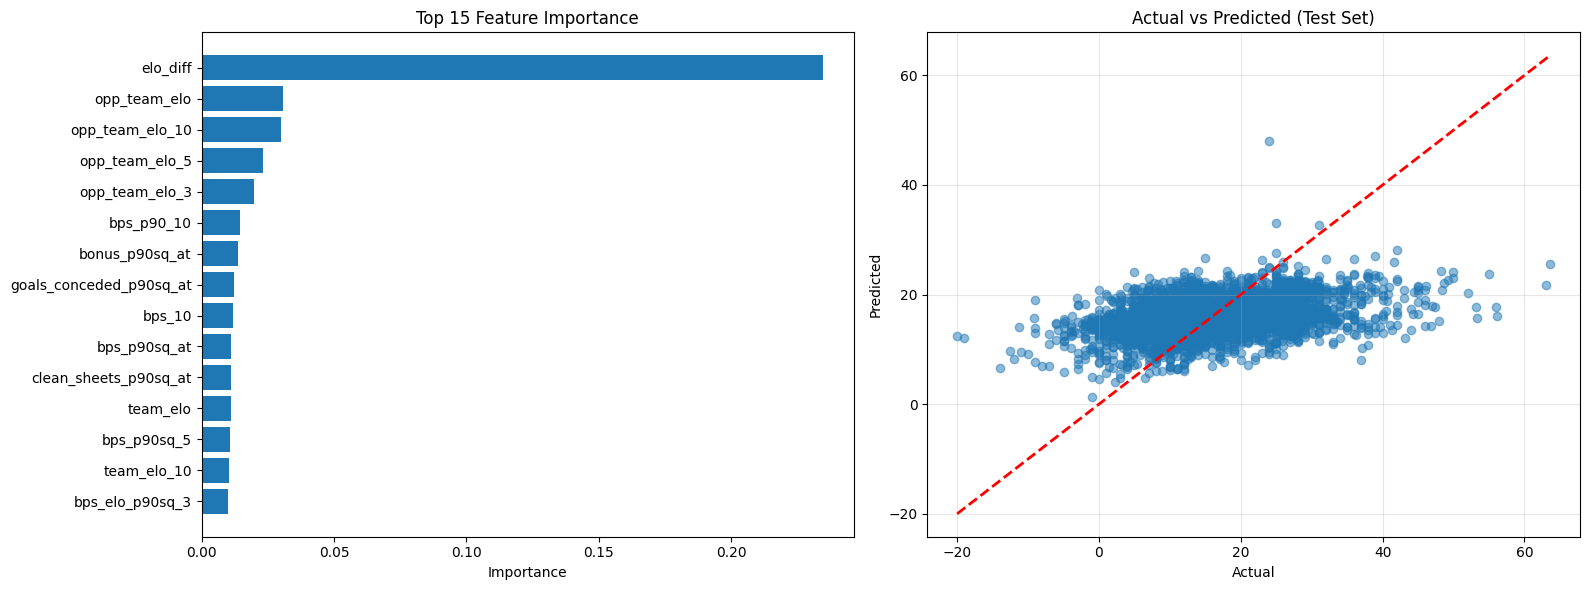

target=bps_per90, GK_bps_predictor
Cleaned df size: 3897/4138

Training Set Performance:
R² Score: 0.5351
RMSE: 6.0874
MAE: 4.9307

Test Set Performance:
R² Score: 0.0380
RMSE: 8.7261
MAE: 7.0003

Top 20 Feature Importances:
                feature  importance
           bps_p90sq_10    0.030960
        opp_team_elo_10    0.026243
           opp_team_elo    0.025639
           bps_p90sq_at    0.023582
  opp_team_elo_p90sq_at    0.021767
  opp_team_elo_p90sq_10    0.021728
  total_points_p90sq_10    0.019653
             bps_p90_10    0.019526
               elo_diff    0.019490
      saves_elo_p90sq_3    0.019243
       bps_elo_p90sq_10    0.018856
            bps_p90sq_3    0.016809
goals_conceded_p90sq_at    0.016804
         saves_p90sq_10    0.015716
        bps_elo_p90sq_3    0.014809
         opp_team_elo_3    0.014762
         saves_p90sq_at    0.014180
         opp_team_elo_5    0.013990
      saves_elo_p90sq_5    0.013974
  total_points_p90sq_at    0.013835


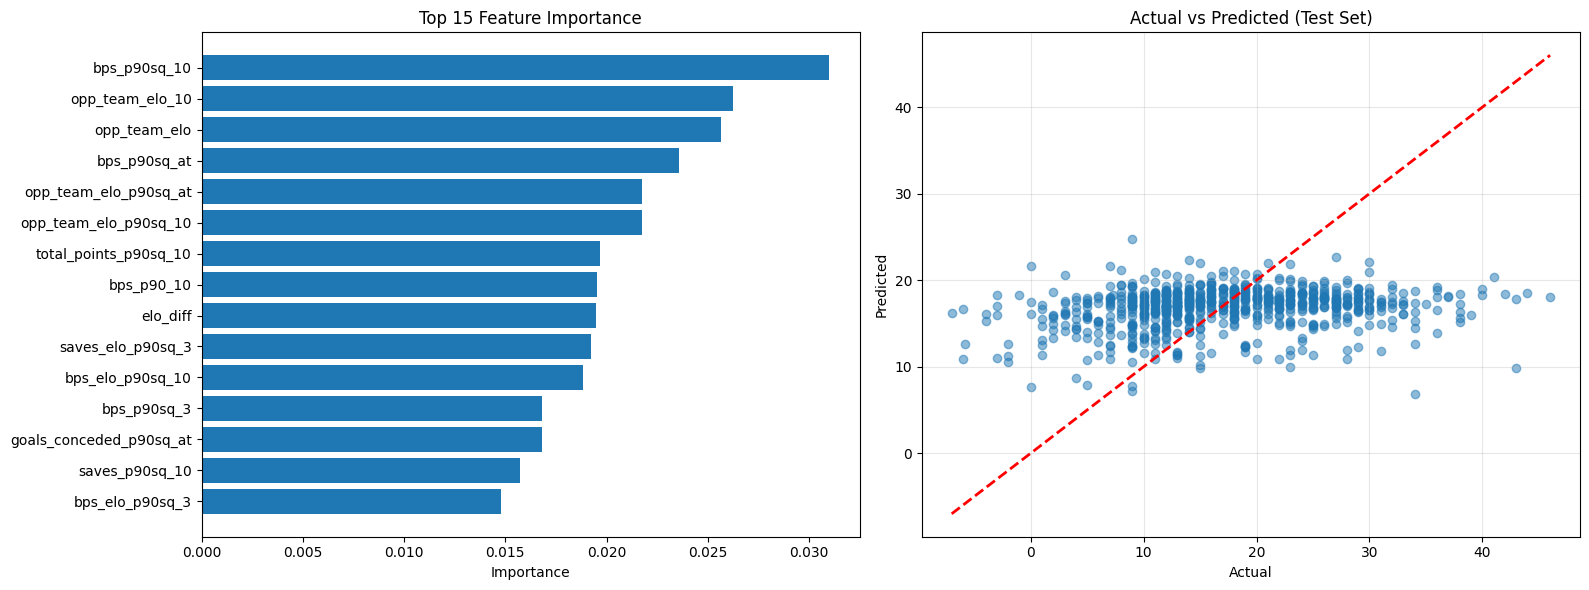

In [16]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 3897/4159

Training Set Performance:
R² Score: 0.5864
RMSE: 1.2763
MAE: 1.0318

Test Set Performance:
R² Score: 0.0116
RMSE: 1.8420
MAE: 1.4627

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.141630
      opp_team_elo_p90sq_at    0.022008
               opp_team_elo    0.021896
             saves_p90sq_at    0.021250
             saves_p90sq_10    0.016419
             opp_team_elo_5    0.016301
            opp_team_elo_10    0.015267
    goals_conceded_p90sq_at    0.014807
          team_elo_p90sq_at    0.013654
             opp_team_elo_3    0.013416
         saves_elo_p90sq_10    0.013061
               bps_p90sq_at    0.012765
      opp_team_elo_p90sq_10    0.012041
             bonus_p90sq_at    0.011523
          saves_elo_p90sq_5    0.011496
      total_points_p90sq_at    0.011126
   total_points_elo_p90sq_3    0.011045
               bps_p90sq_10    0.010876
  total_poi

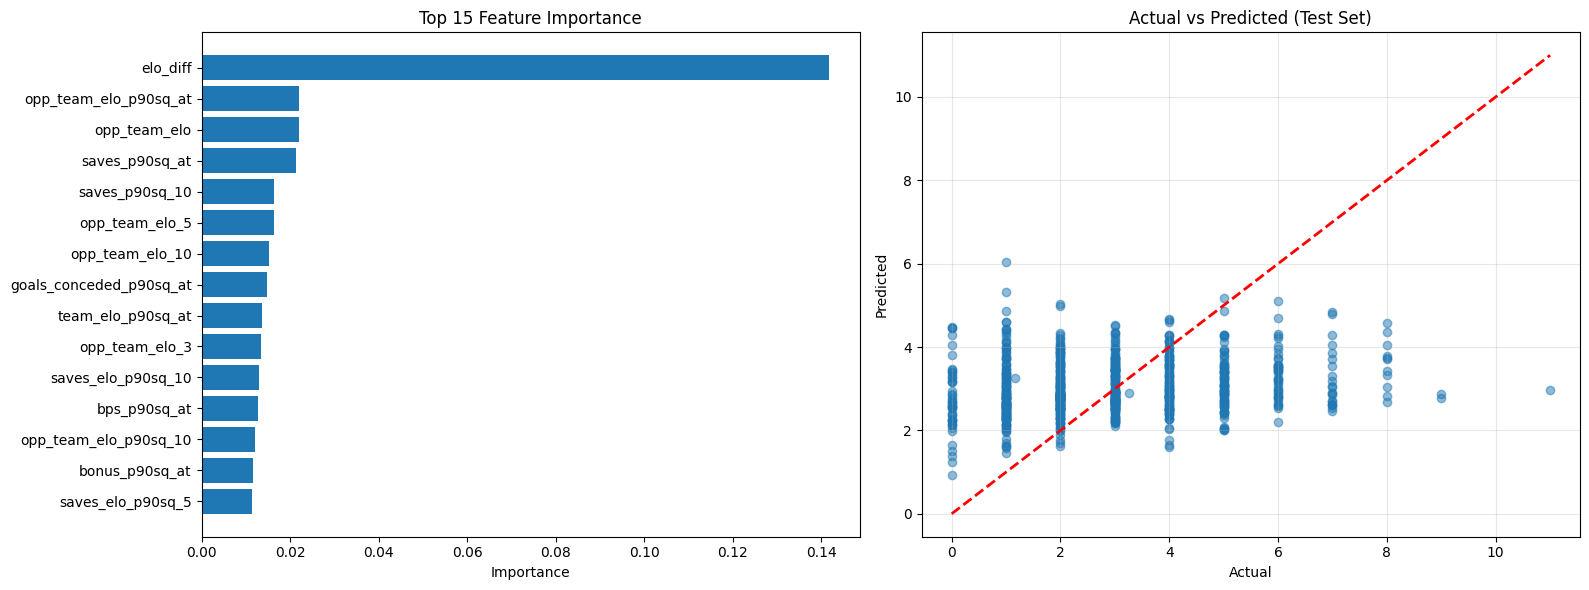

In [17]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 627/5113

Training Set Performance:
R² Score: 0.8000
RMSE: 1.2674
MAE: 1.0157

Test Set Performance:
R² Score: 0.0167
RMSE: 2.6778
MAE: 2.0900

Top 20 Feature Importances:
                  feature  importance
    clean_sheets_p90sq_at    0.043794
           opp_team_elo_5    0.035844
     total_points_p90sq_3    0.029362
    goals_scored_p90sq_at    0.027624
              bps_p90sq_5    0.019908
  goals_conceded_p90sq_at    0.018926
             bps_p90sq_at    0.017188
        team_elo_p90sq_10    0.016188
               minutes_10    0.015581
          opp_team_elo_10    0.015492
             opp_team_elo    0.015055
          xg_over_g_ratio    0.014871
           opp_team_elo_3    0.014793
    total_points_p90sq_at    0.013342
     opp_team_elo_p90sq_5    0.012801
     goals_conceded_p90_5    0.012680
           bonus_p90sq_at    0.011981
opp_team_elo_elo_p90sq_10    0.011863
    goals_scored_p90sq_10    0.

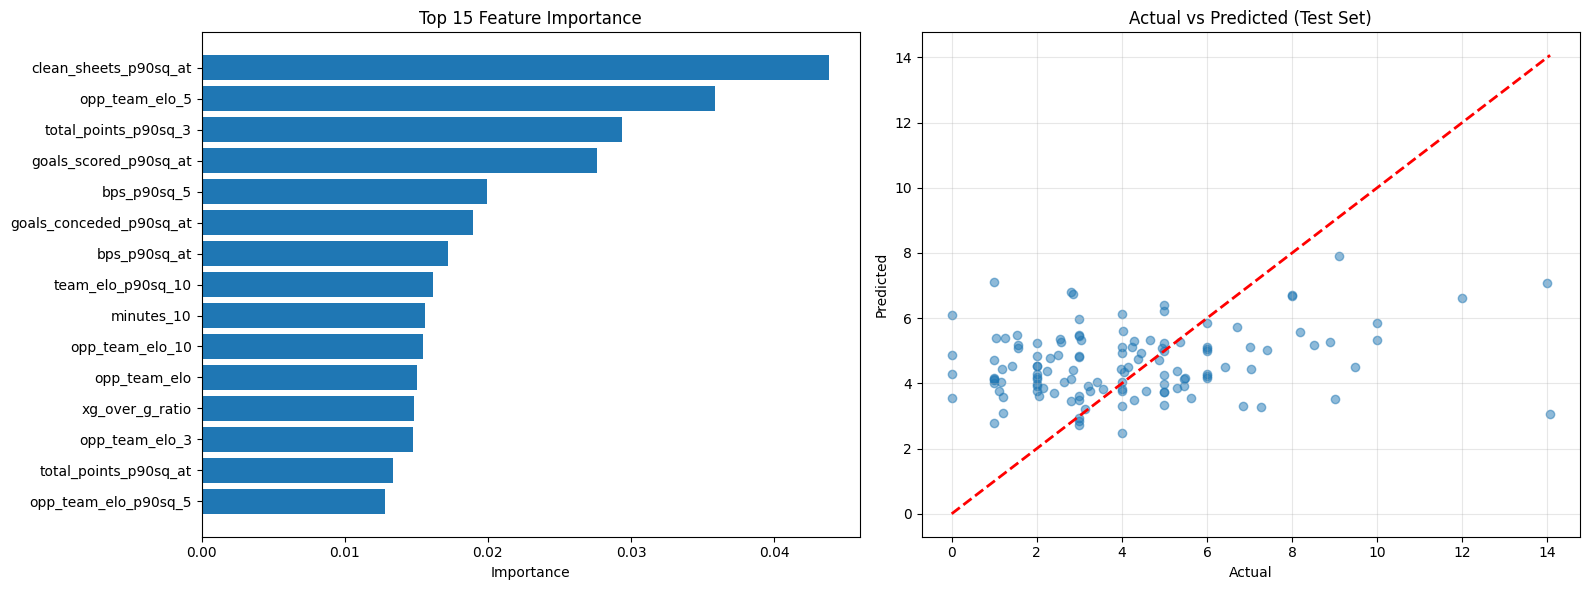

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 2858/21117

Training Set Performance:
R² Score: 0.6586
RMSE: 2.5027
MAE: 2.0106

Test Set Performance:
R² Score: 0.1383
RMSE: 3.5806
MAE: 2.8799

Top 20 Feature Importances:
                    feature  importance
      goals_scored_p90sq_at    0.100254
             bonus_p90sq_at    0.038823
    goals_conceded_p90sq_at    0.031542
      total_points_p90sq_at    0.024171
               bps_p90sq_at    0.016682
                   team_elo    0.015677
                      bps_3    0.014805
      opp_team_elo_p90sq_at    0.012491
           team_elo_p90sq_3    0.012090
           team_elo_p90sq_5    0.012088
             opp_team_elo_3    0.011860
          team_elo_p90sq_at    0.011771
                   elo_diff    0.011721
             opp_team_elo_5    0.011588
      clean_sheets_p90sq_at    0.011514
        team_elo_elo_p90_10    0.011411
               opp_team_elo    0.011221
            opp_team_elo_10    

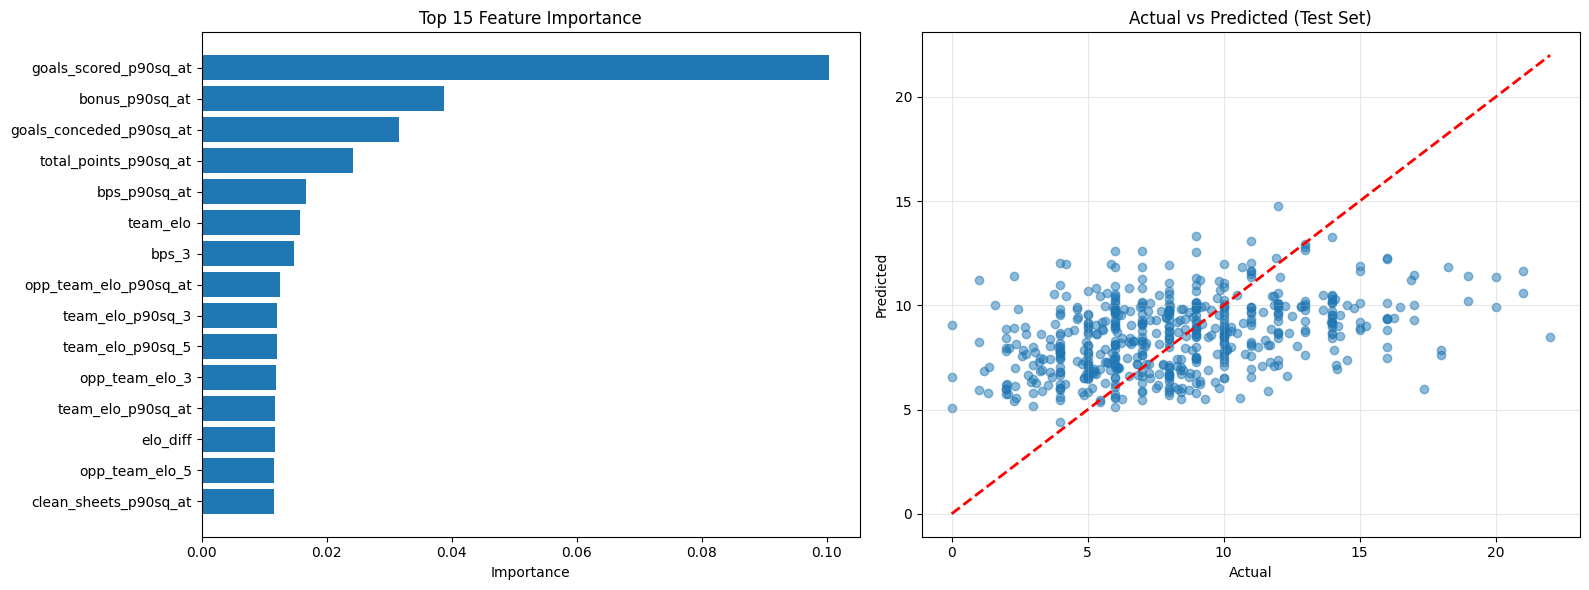

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 2386/17894

Training Set Performance:
R² Score: 0.6683
RMSE: 2.1994
MAE: 1.7871

Test Set Performance:
R² Score: 0.0662
RMSE: 3.8933
MAE: 3.0218

Top 20 Feature Importances:
                                   feature  importance
                                cbi_p90_at    0.074966
                            bonus_p90sq_at    0.023295
                            tackles_p90_at    0.022011
xgoal_involvements_x_defensive_cont_p90_at    0.021365
                              opp_team_elo    0.021154
                                  elo_diff    0.020929
                   opp_team_elo_elo_p90_10    0.019089
                       team_elo_elo_p90_10    0.015696
                               bps_p90sq_3    0.015410
                   goals_conceded_p90sq_at    0.015015
                         recoveries_p90_at    0.014906
                           opp_team_elo_10    0.014717
                     total_points_p9

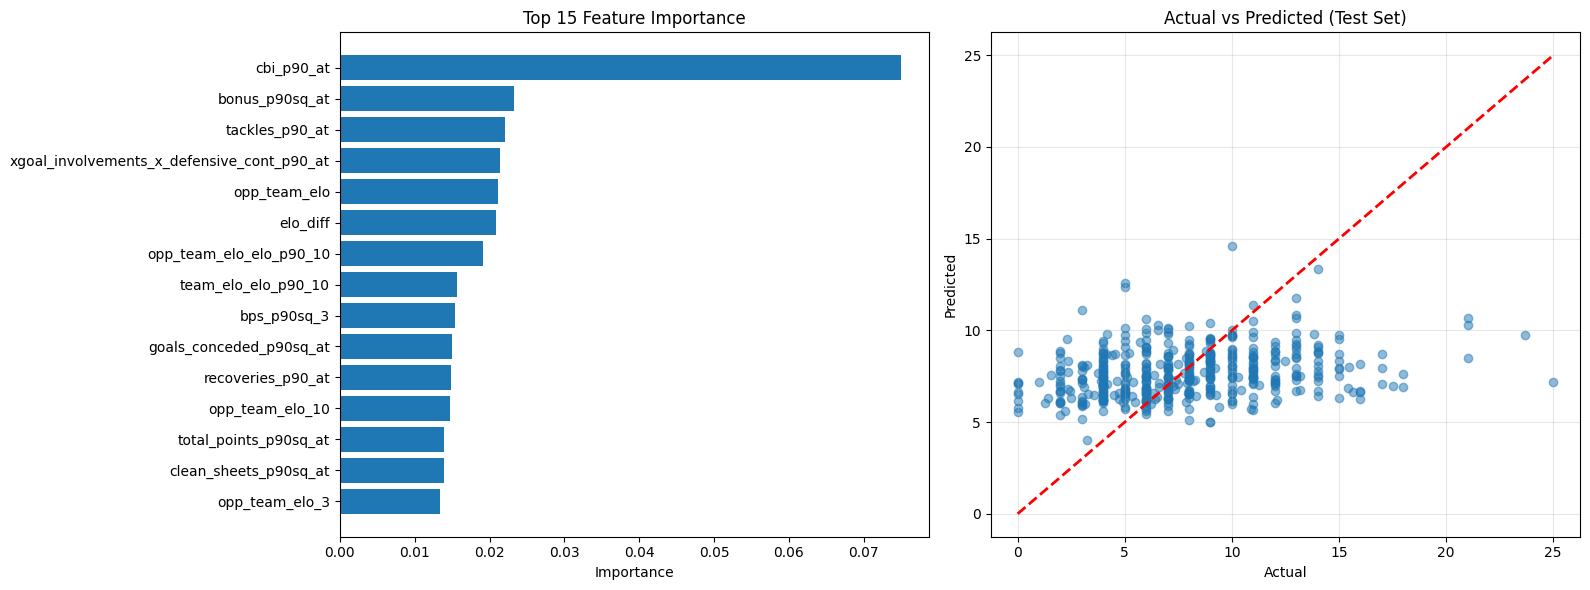

In [18]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

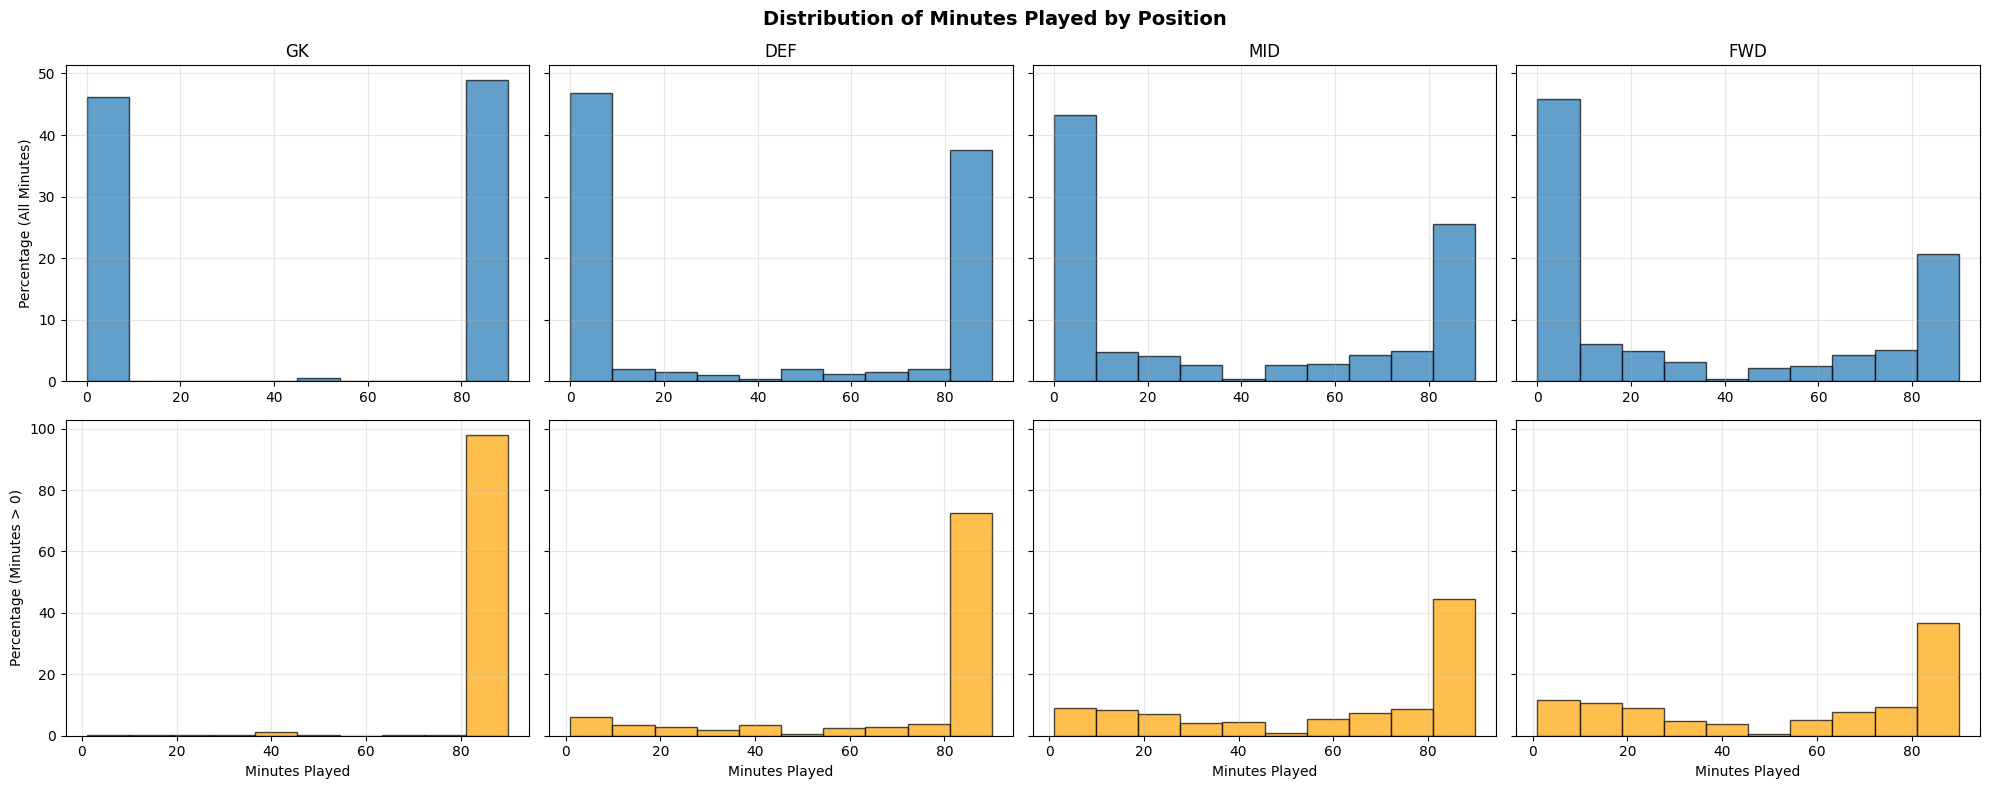

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.357


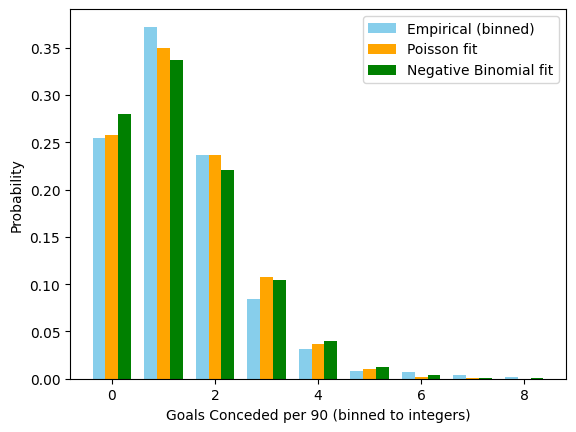

Mean: 1.348, Variance: 1.505
Overdispersion ratio (Var/Mean): 1.117
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.257


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.198


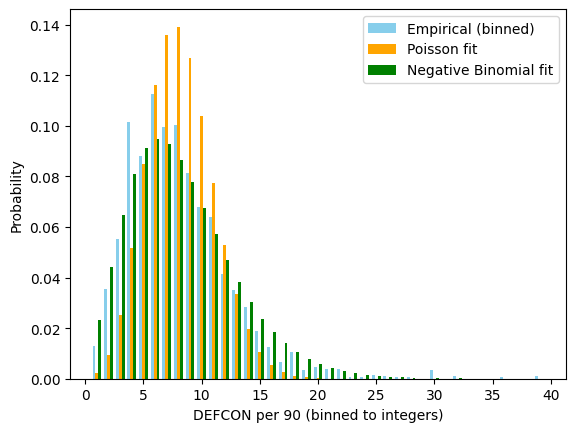

Mean: 8.190, Variance: 21.083
Overdispersion ratio (Var/Mean): 2.574
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [21]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.199


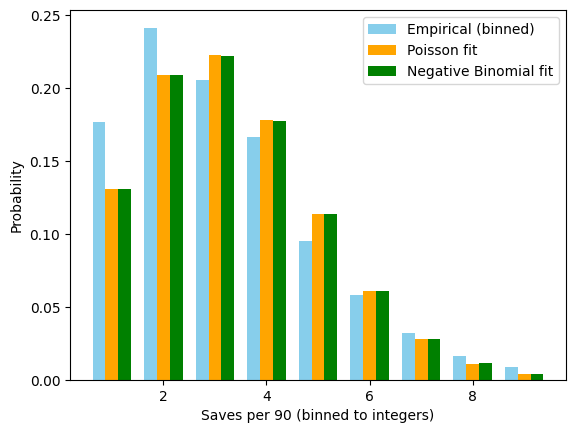

Mean: 3.199, Variance: 3.220
Overdispersion ratio (Var/Mean): 1.007
✅ Poisson assumption looks reasonable.


In [22]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [23]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=current_gw+1)]

In [24]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [25]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_1956\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    4550.000000
mean       60.278121
std        20.194798
min        13.304354
25%        41.173097
50%        61.734042
75%        80.314400
max        89.952658
Name: mins_pred, dtype: float64

In [26]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_1956\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    4250.000000
mean        0.168844
std         0.148459
min         0.027237
25%         0.058948
50%         0.125581
75%         0.216602
max         0.846951
Name: xgp90_pred, dtype: float64

In [27]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_1956\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    4250.000000
mean        0.099614
std         0.060826
min         0.026567
25%         0.051655
50%         0.081255
75%         0.136526
max         0.398889
Name: xap90_pred, dtype: float64

In [28]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_1956\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    4550.000000
mean        1.414383
std         0.311915
min         0.440153
25%         1.194598
50%         1.400280
75%         1.619778
max         2.467745
Name: xgcp90_pred, dtype: float64

In [29]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_1956\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    4550.000000
mean       15.741943
std         3.245662
min         4.091370
25%        13.678996
50%        15.419026
75%        17.555841
max        47.142664
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.448
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                          3.498e+04
Date:                Mon, 09 Mar 2026   Prob (F-statistic):                        0.00
Time:                        11:36:25   Log-Likelihood:                         -40529.
No. Observations:               43034   AIC:                                  8.106e+04
Df Residuals:                   43033   BIC:                                  8.107e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

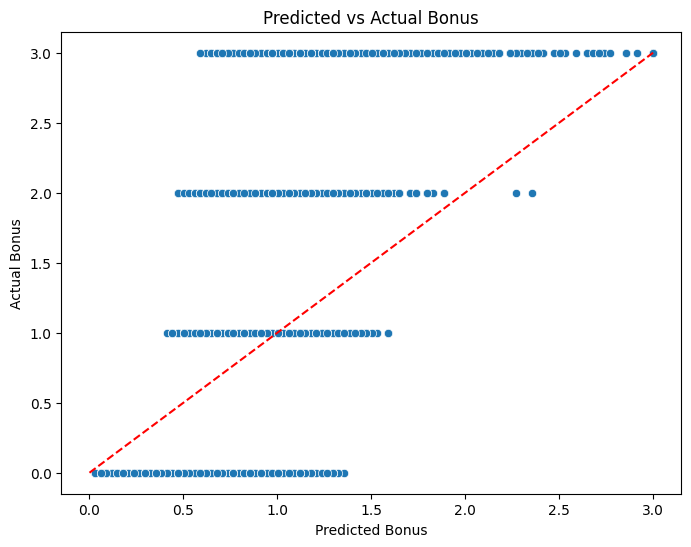

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.458804  0.228572  1.105585  1.946867
FWD           0.332845  0.195936  1.045847  1.706752
GK            0.487775  0.243882  1.113601  2.005940
GKP                NaN       NaN       NaN       NaN
MID           0.397267  0.244501  1.047805  1.822570


C:\Users\Chris\AppData\Local\Temp\ipykernel_1956\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [30]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [31]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_1956\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [32]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_1956\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    300.000000
mean       3.198624
std        0.690715
min        1.364644
25%        2.713467
50%        3.150594
75%        3.496188
max        5.733954
Name: xsavesp90_pred, dtype: float64

In [33]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_1956\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    4250.000000
mean        7.989111
std         1.871002
min         3.345753
25%         6.741374
50%         7.999300
75%         9.402647
max        15.003069
Name: xdefconp90_pred, dtype: float64

In [34]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
130046,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,30.0,Man City,1232.697317,27.198206,0.117478,0.083850,2.125280
130048,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,31.0,Aston Villa,1136.792544,27.035520,0.109392,0.086780,1.782392
130050,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,32.0,Wolves,942.107583,26.933469,0.125388,0.113594,1.206880
130058,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,33.0,Crystal Palace,1049.725045,27.035520,0.090207,0.085423,1.677488
130060,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,34.0,Everton,1068.541563,27.035520,0.090771,0.081073,1.653330


In [35]:
prediction_data[
    (prediction_data['event']==current_gw+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
130399,Alexander Isak,499.0,103.0,Liverpool,FWD,20252026.0,30.0,Spurs,961.910656,32.607246,0.846951,0.255401,1.552927
134365,Eddie Nketiah,284.0,54.0,Crystal Palace,FWD,20252026.0,30.0,Leeds,979.720129,42.096728,0.802970,0.232991,1.783352
138143,Jean-Philippe Mateta,283.0,75.0,Crystal Palace,FWD,20252026.0,30.0,Leeds,979.720129,46.868660,0.785058,0.285859,1.420065
141573,Marc Guiu Paz,252.0,41.0,Chelsea,FWD,20252026.0,30.0,Newcastle,1078.356498,47.044816,0.780444,0.298576,1.564460
144330,Odsonne Édouard,285.0,50.0,Crystal Palace,FWD,20252026.0,30.0,Leeds,979.720129,26.489623,0.777199,0.234537,1.905090
132420,Callum Marshall,626.0,43.0,West Ham,FWD,20252026.0,30.0,Man City,1232.697317,40.766701,0.713867,0.219571,2.420430
143948,Niclas Füllkrug,625.0,56.0,West Ham,FWD,20252026.0,30.0,Man City,1232.697317,34.613330,0.673477,0.246223,2.422163
146660,Saša Kalajdžić,656.0,49.0,Wolves,FWD,20252026.0,30.0,Brentford,1079.913962,40.817071,0.650332,0.233250,2.252426
135648,Fábio Freitas Gouveia Carvalho,123.0,47.0,Brentford,MID,20252026.0,30.0,Wolves,942.107583,40.078481,0.650119,0.398889,1.776892
147200,Stefanos Tzimas,180.0,52.0,Brighton,FWD,20252026.0,30.0,Sunderland,1037.633854,37.664585,0.645018,0.256326,1.506374


In [36]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [37]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [38]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_1956\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_1956\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_

In [39]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]

In [40]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4550 entries, 0 to 4549
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          4550 non-null   object 
 1   team_name               4550 non-null   object 
 2   team_elo                4550 non-null   float64
 3   element                 4550 non-null   float64
 4   position                4550 non-null   object 
 5   opp_team_name           4550 non-null   object 
 6   opp_team_elo            4550 non-null   float64
 7   season                  4550 non-null   float64
 8   value                   4550 non-null   float64
 9   event                   4550 non-null   float64
 10  mins_pred               4550 non-null   float64
 11  xgp90_pred              4250 non-null   float64
 12  xap90_pred              4250 non-null   float64
 13  xgcp90_pred             4550 non-null   float64
 14  xpoints_mins            4550 non-null   

In [41]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [42]:
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
""")

In [43]:
print(f"Gameweek {current_gw+1} Predictions")
prediction_data[
    prediction_data['event']==current_gw+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 30 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
131066,Antoine Semenyo,82.0,30.0,82.0,Man City,MID,West Ham,987.690956,85.421019,1.927041,1.486807,0.508820,0.447941,0.0,0.000000,0.509972,0.636864,5.517445
144056,Nico O'Reilly,411.0,30.0,51.0,Man City,DEF,West Ham,987.690956,69.296323,1.717001,0.594031,0.167813,1.810841,0.0,-0.197488,0.537122,0.641767,5.271087
142345,Matheus Nunes,407.0,30.0,54.0,Man City,DEF,West Ham,987.690956,86.221968,1.932277,0.256394,0.216847,1.808875,0.0,-0.197920,0.537122,0.648120,5.201714
132955,Cody Gakpo,384.0,30.0,73.0,Liverpool,MID,Spurs,961.910656,74.644287,1.812209,1.279143,0.501286,0.450049,0.0,0.000000,0.509972,0.599923,5.152582
133037,Conor Bradley,375.0,30.0,49.0,Liverpool,DEF,Spurs,961.910656,68.658143,1.703874,0.739318,0.432001,1.424372,0.0,-0.297982,0.537122,0.612352,5.151056
146510,Rúben dos Santos Gato Alves Dias,408.0,30.0,55.0,Man City,DEF,West Ham,987.690956,82.997323,1.908855,0.239650,0.118677,1.848061,0.0,-0.189443,0.537122,0.632198,5.095119
141807,Marc Guéhi,260.0,30.0,52.0,Man City,DEF,West Ham,987.690956,85.235461,1.925776,0.262092,0.129886,1.823326,0.0,-0.194762,0.537122,0.608842,5.092282
136902,Ibrahima Konaté,374.0,30.0,55.0,Liverpool,DEF,Spurs,961.910656,86.602563,1.934640,0.239162,0.138707,1.835571,0.0,-0.192115,0.537122,0.586623,5.079709
143321,Milos Kerkez,371.0,30.0,56.0,Liverpool,DEF,Spurs,961.910656,83.716046,1.914636,0.220593,0.160649,1.803810,0.0,-0.199036,0.537122,0.598543,5.036316
142485,Max Alleyne,794.0,30.0,40.0,Man City,DEF,West Ham,987.690956,62.199772,1.554774,0.800555,0.100429,1.634631,0.0,-0.239189,0.537122,0.638546,5.026867


In [44]:
print(f"Next 5 GWs: GW{current_gw+1} - GW{current_gw+5}")
next_5_gws_filter = (prediction_data['event']>=current_gw)&(prediction_data['event']<=current_gw+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW30 - GW34


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
84,Cody Gakpo,373.726149,9.068713,5.754780,2.601363,1.706515,0.0,0.000000,2.549859,2.729980,24.411211
359,Mohamed Salah,399.614434,9.399925,5.341864,2.224600,1.558666,0.0,0.000000,2.549859,2.474794,23.549709
15,Alexis Mac Allister,415.351230,9.547286,4.908964,2.207251,1.567127,0.0,0.000000,2.549859,2.684988,23.465473
64,Bruno Borges Fernandes,385.637934,9.235969,4.383338,2.953293,1.342370,0.0,0.000000,2.549859,2.986777,23.451606
85,Cole Palmer,384.283134,9.218254,4.368504,2.461765,1.193195,0.0,0.000000,2.549859,3.506868,23.298445
86,Conor Bradley,343.343119,8.520462,3.843255,1.938127,5.337556,0.0,-2.174308,2.685609,2.822958,22.973660
118,Dominik Szoboszlai,428.179136,9.642404,3.731893,2.518638,1.543239,0.0,0.000000,2.549859,2.927179,22.913211
239,John McGinn,270.512201,6.783549,7.670318,1.730128,1.417445,0.0,0.000000,2.549859,2.714825,22.866124
333,Matheus Santos Carneiro da Cunha,419.425935,9.579738,4.692976,1.974629,1.348916,0.0,0.000000,2.549859,2.617565,22.763684
362,Morgan Gibbs-White,411.681637,9.516147,4.201635,2.289230,1.523046,0.0,0.000000,2.549859,2.670578,22.750495


In [45]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
84,Cody Gakpo,672.140010,16.315003,10.049056,4.472118,2.967466,0.0,0.0,4.589746,4.802610,43.195998
85,Cole Palmer,691.771421,16.593671,8.157667,4.488844,2.320509,0.0,0.0,4.589746,6.334766,42.485203
64,Bruno Borges Fernandes,694.148282,16.624744,7.799305,5.513263,2.498546,0.0,0.0,4.589746,5.407411,42.433014
359,Mohamed Salah,719.305982,16.919866,9.621108,3.820176,2.599909,0.0,0.0,4.589746,4.439328,41.990132
15,Alexis Mac Allister,747.632214,17.185114,8.775028,3.906503,2.639371,0.0,0.0,4.589746,4.731898,41.827660
32,Antoine Semenyo,683.145624,15.414804,10.338189,3.911855,3.044586,0.0,0.0,4.079774,4.823610,41.612819
239,John McGinn,488.045764,12.236338,13.821904,2.964418,2.634846,0.0,0.0,4.589746,4.840564,41.087817
333,Matheus Santos Carneiro da Cunha,754.966682,17.243528,8.436915,3.537850,2.478979,0.0,0.0,4.589746,4.716438,41.003456
363,Morgan Rogers,761.319154,17.291020,7.970405,3.911971,2.529567,0.0,0.0,4.589746,4.466463,40.759172
118,Dominik Szoboszlai,770.722446,17.356327,6.610121,4.306199,2.547241,0.0,0.0,4.589746,5.149809,40.559442


In [46]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': current_gw
})

In [47]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [48]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            pg.fixture, pg.total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    WHERE 1=0;  -- Empty table with correct schema
""")

In [49]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 4550 new predictions to predictions_allgws


In [50]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==current_gw) & (
    view['event']==current_gw+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points']][future_filter].head()

,player_name_id,event,season,total_points
87899,Erling Haaland,30.0,20252026.0,NaN


In [51]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=13)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].head(10)

,player_name_id,event,season,total_points,minutes
182923,Erling Haaland,13.0,20252026.0,2.0,90.0
182924,Erling Haaland,14.0,20252026.0,14.0,90.0
182925,Erling Haaland,15.0,20252026.0,2.0,68.0
182926,Erling Haaland,16.0,20252026.0,13.0,90.0
182927,Erling Haaland,17.0,20252026.0,16.0,90.0
182928,Erling Haaland,18.0,20252026.0,2.0,90.0
182929,Erling Haaland,19.0,20252026.0,2.0,90.0
182930,Erling Haaland,20.0,20252026.0,2.0,90.0
182931,Erling Haaland,21.0,20252026.0,6.0,90.0
182932,Erling Haaland,22.0,20252026.0,2.0,79.0


In [52]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
5663,Erling Haaland,2026-01-26 14:27:00.627006,24.0,4.148815,NaN
...,...,...,...,...,...
77213,Erling Haaland,2026-02-23 12:07:30.733847,38.0,4.533205,NaN
71670,Erling Haaland,2026-02-22 11:15:02.719357,38.0,4.363917,NaN
65863,Erling Haaland,2026-02-20 10:52:25.776847,38.0,4.434418,NaN
82767,Erling Haaland,2026-02-24 10:14:37.233826,38.0,4.475827,NaN


In [53]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=current_gw)&(
                df_preds['event']<=current_gw+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2026-01-05 18:33:33.065519 20                  20252026.0 29.0   3.392790
                                                          30.0   3.432445
                                                          31.0   3.432435
                                                          32.0   3.417936
                                                          33.0   3.403198
...                                                                   ...
2026-03-09 11:36:31.677192 29                  20252026.0 30.0   3.441963
                                                          31.0   3.430686
                                                          32.0   3.443239
                                                          33.0   3.426558
                                                          34.0   3.454941

[107 rows x 1 columns]

In [54]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2910
2026-01-07 16:29:20.849190,12
2026-01-08 16:44:49.940956,12
2026-01-22 16:59:38.976316,18
2026-01-25 11:24:25.347489,6
2026-01-26 14:27:00.627006,2970
2026-01-27 11:00:04.422834,2976
2026-02-01 11:57:12.353330,2988
2026-02-02 13:38:00.840050,3006


In [55]:
df_complete.columns.to_list()

['player_name_id',
 'team_name',
 'team_elo',
 'element',
 'position',
 'opp_team_name',
 'opp_team_elo',
 'season',
 'value',
 'event',
 'mins_pred',
 'xgp90_pred',
 'xap90_pred',
 'xgcp90_pred',
 'xpoints_mins',
 'xpoints_goals',
 'xpoints_assists',
 'xpoints_clean_sheets',
 'xpoints_shots_saved',
 'xpoints_goals_conceded',
 'xpoints_defcon',
 'xpoints_bonus',
 'xpoints',
 'in_any_team',
 'in_my_team',
 'prediction_timestamp',
 'prediction_gameweek',
 'total_points',
 'fixture']

In [56]:
filtered = (df_complete['player_name_id'] == 'Bukayo Saka')&(
    df_complete['season']==20252026) & (df_complete['event']==25)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,xpoints,total_points


In [57]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,24,24.000000
mean,2026-01-08 04:37:05.395073024,31.500000
min,2026-01-07 16:29:20.849190,29.000000
25%,2026-01-07 16:29:20.849189888,30.000000
50%,2026-01-08 04:37:05.395073024,31.500000
75%,2026-01-08 16:44:49.940955904,33.000000
max,2026-01-08 16:44:49.940956,34.000000
std,NaN,1.744557


In [58]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{current_gw}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [59]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 32.86 minute(s)


In [60]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)